In [1]:
import xarray as xr
import numpy as np
import gsw
from matplotlib import cm
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import ffmpeg
import pylab as pl
import pandas as pd
from math import radians, cos, sin
from matplotlib.gridspec import GridSpec

In [2]:
project='twoBumps'
ed='run3/'

directory='/Users/ameliameggo/Proyecto/Codigo/NGC/'+ str(project)
dataloc=str(directory)+ '/' + str(ed)
location= str(directory) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

#location='/home/amelia/NGC/'+ str(project) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

var='dynDiag'

ds=xr.open_dataset(str(location) +  str(var) + '.nc')


varS='surfDiag'

dsS=xr.open_dataset(str(location) +  str(varS) + '.nc')

varG='grid'

dsG=xr.open_dataset(str(location) +  str(varG) + '.nc')


#Take them minus 1 and 2 to skip the boundary
ny=len(dsG.Y)
nx=len(dsG.X) 
nz=len(dsG.Z)
nt=len(ds.T) 

if project=='twoBumps':
    umbral1=np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0][int(len(np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0])/2)]
    umbral2=np.where(dsG.Depth[int(ny/2):,20].values==np.min(dsG.Depth[int(ny/2):,20].values))[0][int(len(np.where(dsG.Depth[int(ny/2):,20].values==600)[0])/2)]+int(ny/2)

    umbralEnd1=np.where(dsG.Depth[:int(ny/2),20]<np.max(dsG.Depth[:int(ny/2),20]))[0][-1]
    umbralEnd2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][-1]+int(ny/2)
else:
    umbral=np.where(dsG.Depth[:,20].values==np.min(dsG.Depth[:,20].values))[0][int(len(np.where(dsG.Depth[:,20].values==np.min(dsG.Depth[:,20].values))[0])/2)]
    umbralEnd=np.where(dsG.Depth[:,20]<np.max(dsG.Depth[:,20]))[0][-1]

hFacC = dsG.HFacC

hfa = np.ma.masked_values(hFacC, 0)
mask = np.ma.getmask(hfa)

hFacW = dsG.HFacW

hfaW = np.ma.masked_values(hFacW, 0)
maskw = np.ma.getmask(hfaW)

hFacS = dsG.HFacS

hfaS = np.ma.masked_values(hFacS, 0)
masks = np.ma.getmask(hfaS)

#info=pd.read_csv(str(dataloc) + 'data',sep='/n')
#parameters=['viscAh','viscAr','diffKhT','diffKrT']


if project == '2Dsill':
    OB=1
    OBend=-1
elif project =='2DsillOB':
    OBp=1
    OBendp=-1
    OB=21
    OBend=-1
elif project =='OpenNorth' or project =='Orlanski':
    OBp=1
    OBendp=-1
    OB=10
    OBend=-10
    OBx=1
    OBendx=-1
else:
    OBp=1
    OBendp=-1
    OB=20
    OBend=-20
    OBx=1
    OBendx=-1

In [3]:
start=np.where(ds.T/(60*60*24*360)>1)[0][0]
end =np.where(ds.T/(60*60*24*360)<=2)[0][-1] # np.where(np.isnan(ds.WVEL[:,10,10,5])==False)[0][-1] #

In [4]:
params = {'font.size': 10,
          'figure.figsize': (10, 10),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [5]:
closS=umbral1 #int(ny*0.4)
closE=umbralEnd1 #np.where(dsG.Y>=130000)[0][0] #np.where(dsG.Y>=260000)[0][0]
depS=np.where(dsG.Z>=-400)[0][-1]
depE=np.where(dsG.Z>=-700)[0][-1]

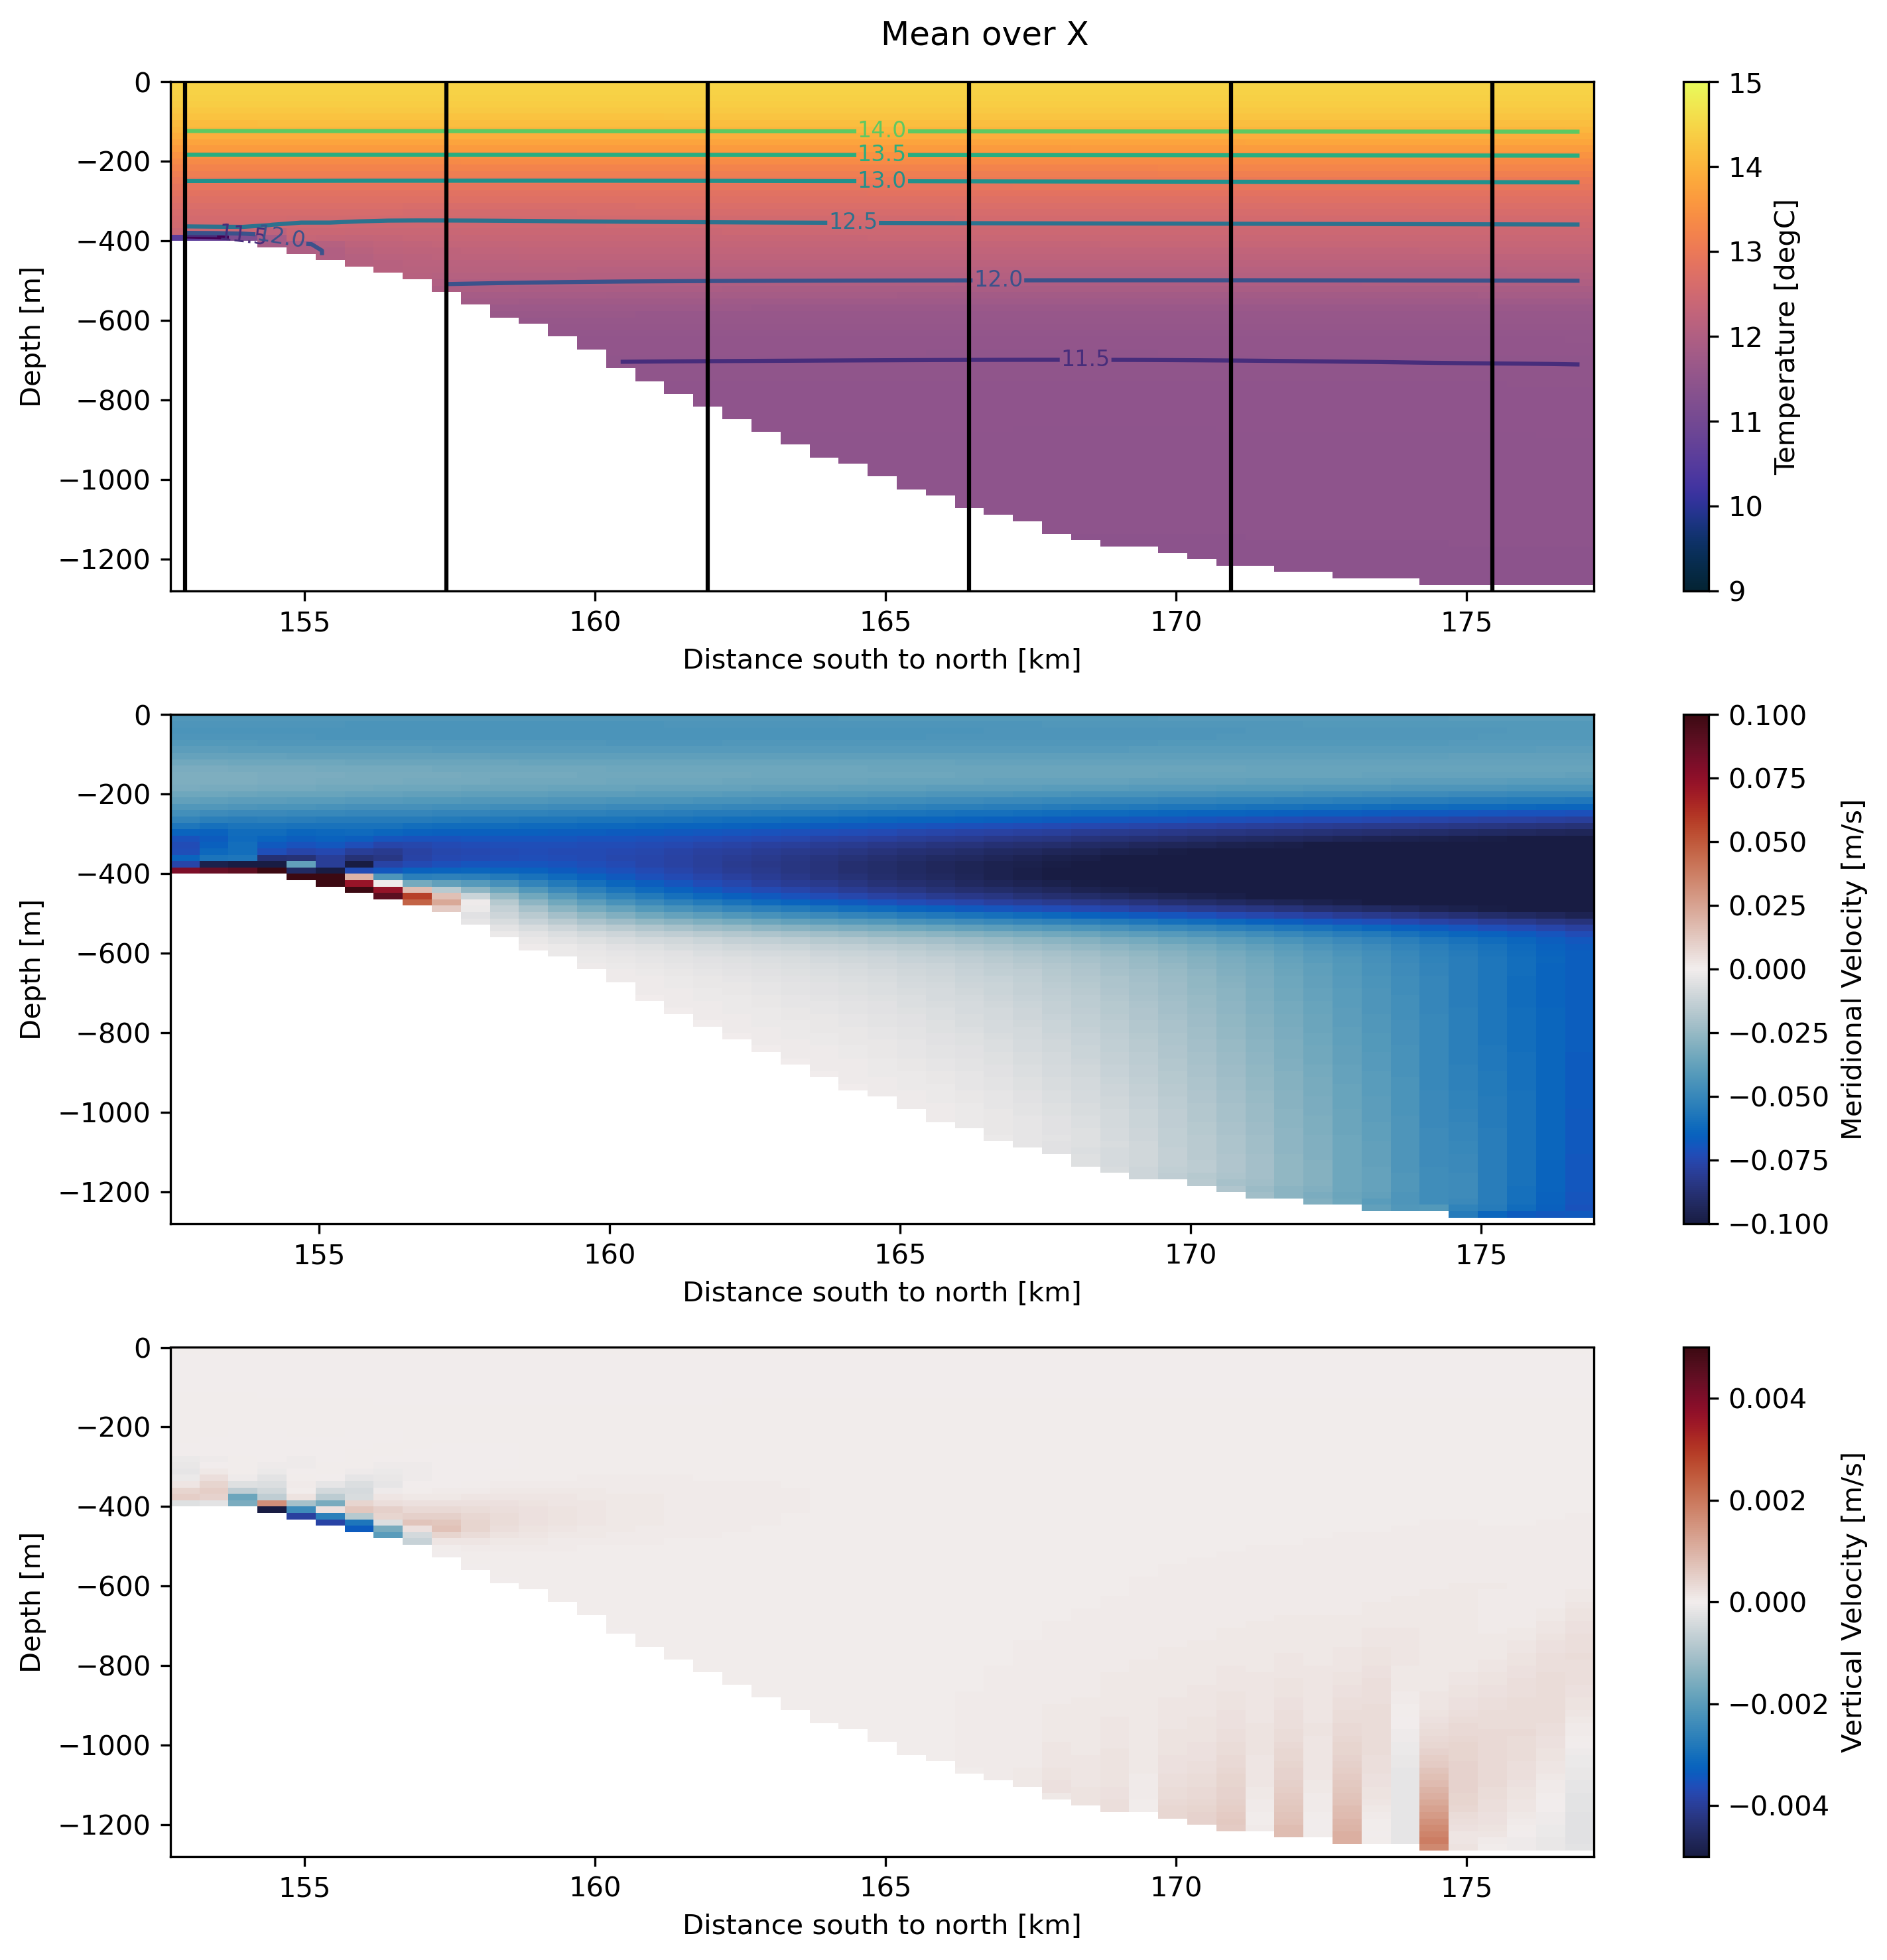

In [6]:
indX=np.arange(4,6,1) #-2#1 #int(nx/2)
end=-1

lines=np.arange(umbral1,umbralEnd1,int((umbralEnd1-umbral1)/5))

fig,ax=plt.subplots(3)
axin=ax[0]
cax=axin.pcolormesh(dsG.Y[closS:closE]/1000,dsG.Z,np.mean(np.ma.masked_array(ds.THETA[end,:,closS:closE,indX],mask=mask[:,closS:closE,indX]),axis=2),vmin=9,vmax=15,cmap=cmocean.cm.thermal)
levels=[11,11.5,12,12.5,13,13.5,14,15]
caxC=axin.contour(dsG.Y[closS:closE]/1000,dsG.Z,np.mean(np.ma.masked_array(ds.THETA[end,:,closS:closE,indX],mask=mask[:,closS:closE,indX]),axis=2),levels=levels)
axin.clabel(caxC, inline=1, fontsize=8)
for line in lines:
    axin.axvline(dsG.Y[line]/1000,color='k')

axin.set(xlabel='Distance south to north [km]',ylabel='Depth [m]')
    
cbar=plt.colorbar(cax)
cbar.set_label('Temperature [degC]')

axin=ax[1]
cax=axin.pcolormesh(dsG.Yp1[closS:closE]/1000,dsG.Z,np.mean(np.ma.masked_array(ds.VVEL[end,:,closS:closE,indX],mask=masks[:,closS:closE,indX]),axis=2),vmin=-0.1,vmax=0.1,cmap=cmocean.cm.balance)

axin.set(xlabel='Distance south to north [km]',ylabel='Depth [m]')
    
cbar=plt.colorbar(cax)
cbar.set_label('Meridional Velocity [m/s]')

axin=ax[2]
cax=axin.pcolormesh(dsG.Y[closS:closE]/1000,dsG.Z,np.mean(np.ma.masked_array(ds.WVEL[end,:,closS:closE,indX],mask=mask[:,closS:closE,indX]),axis=2),vmin=-0.005,vmax=0.005,cmap=cmocean.cm.balance)


cbar=plt.colorbar(cax)
cbar.set_label('Vertical Velocity [m/s]')
axin.set(xlabel='Distance south to north [km]',ylabel='Depth [m]')
fig.suptitle('Mean over X')
fig.tight_layout()

plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'CloseUpUmbMeanUmb1.png', bbox_inches='tight')

np.mean(np.ma.masked_array(np.mean(ds.VVEL[start:,:,umbral+step,1:int(len(dsG.X[1:-1])/2)],axis=0),mask=mask[:,umbral+step,1:int(len(dsG.X[1:-1])/2)]),axis=1)

In [7]:
params = {'font.size': 10,
          'figure.figsize': (10, 5),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

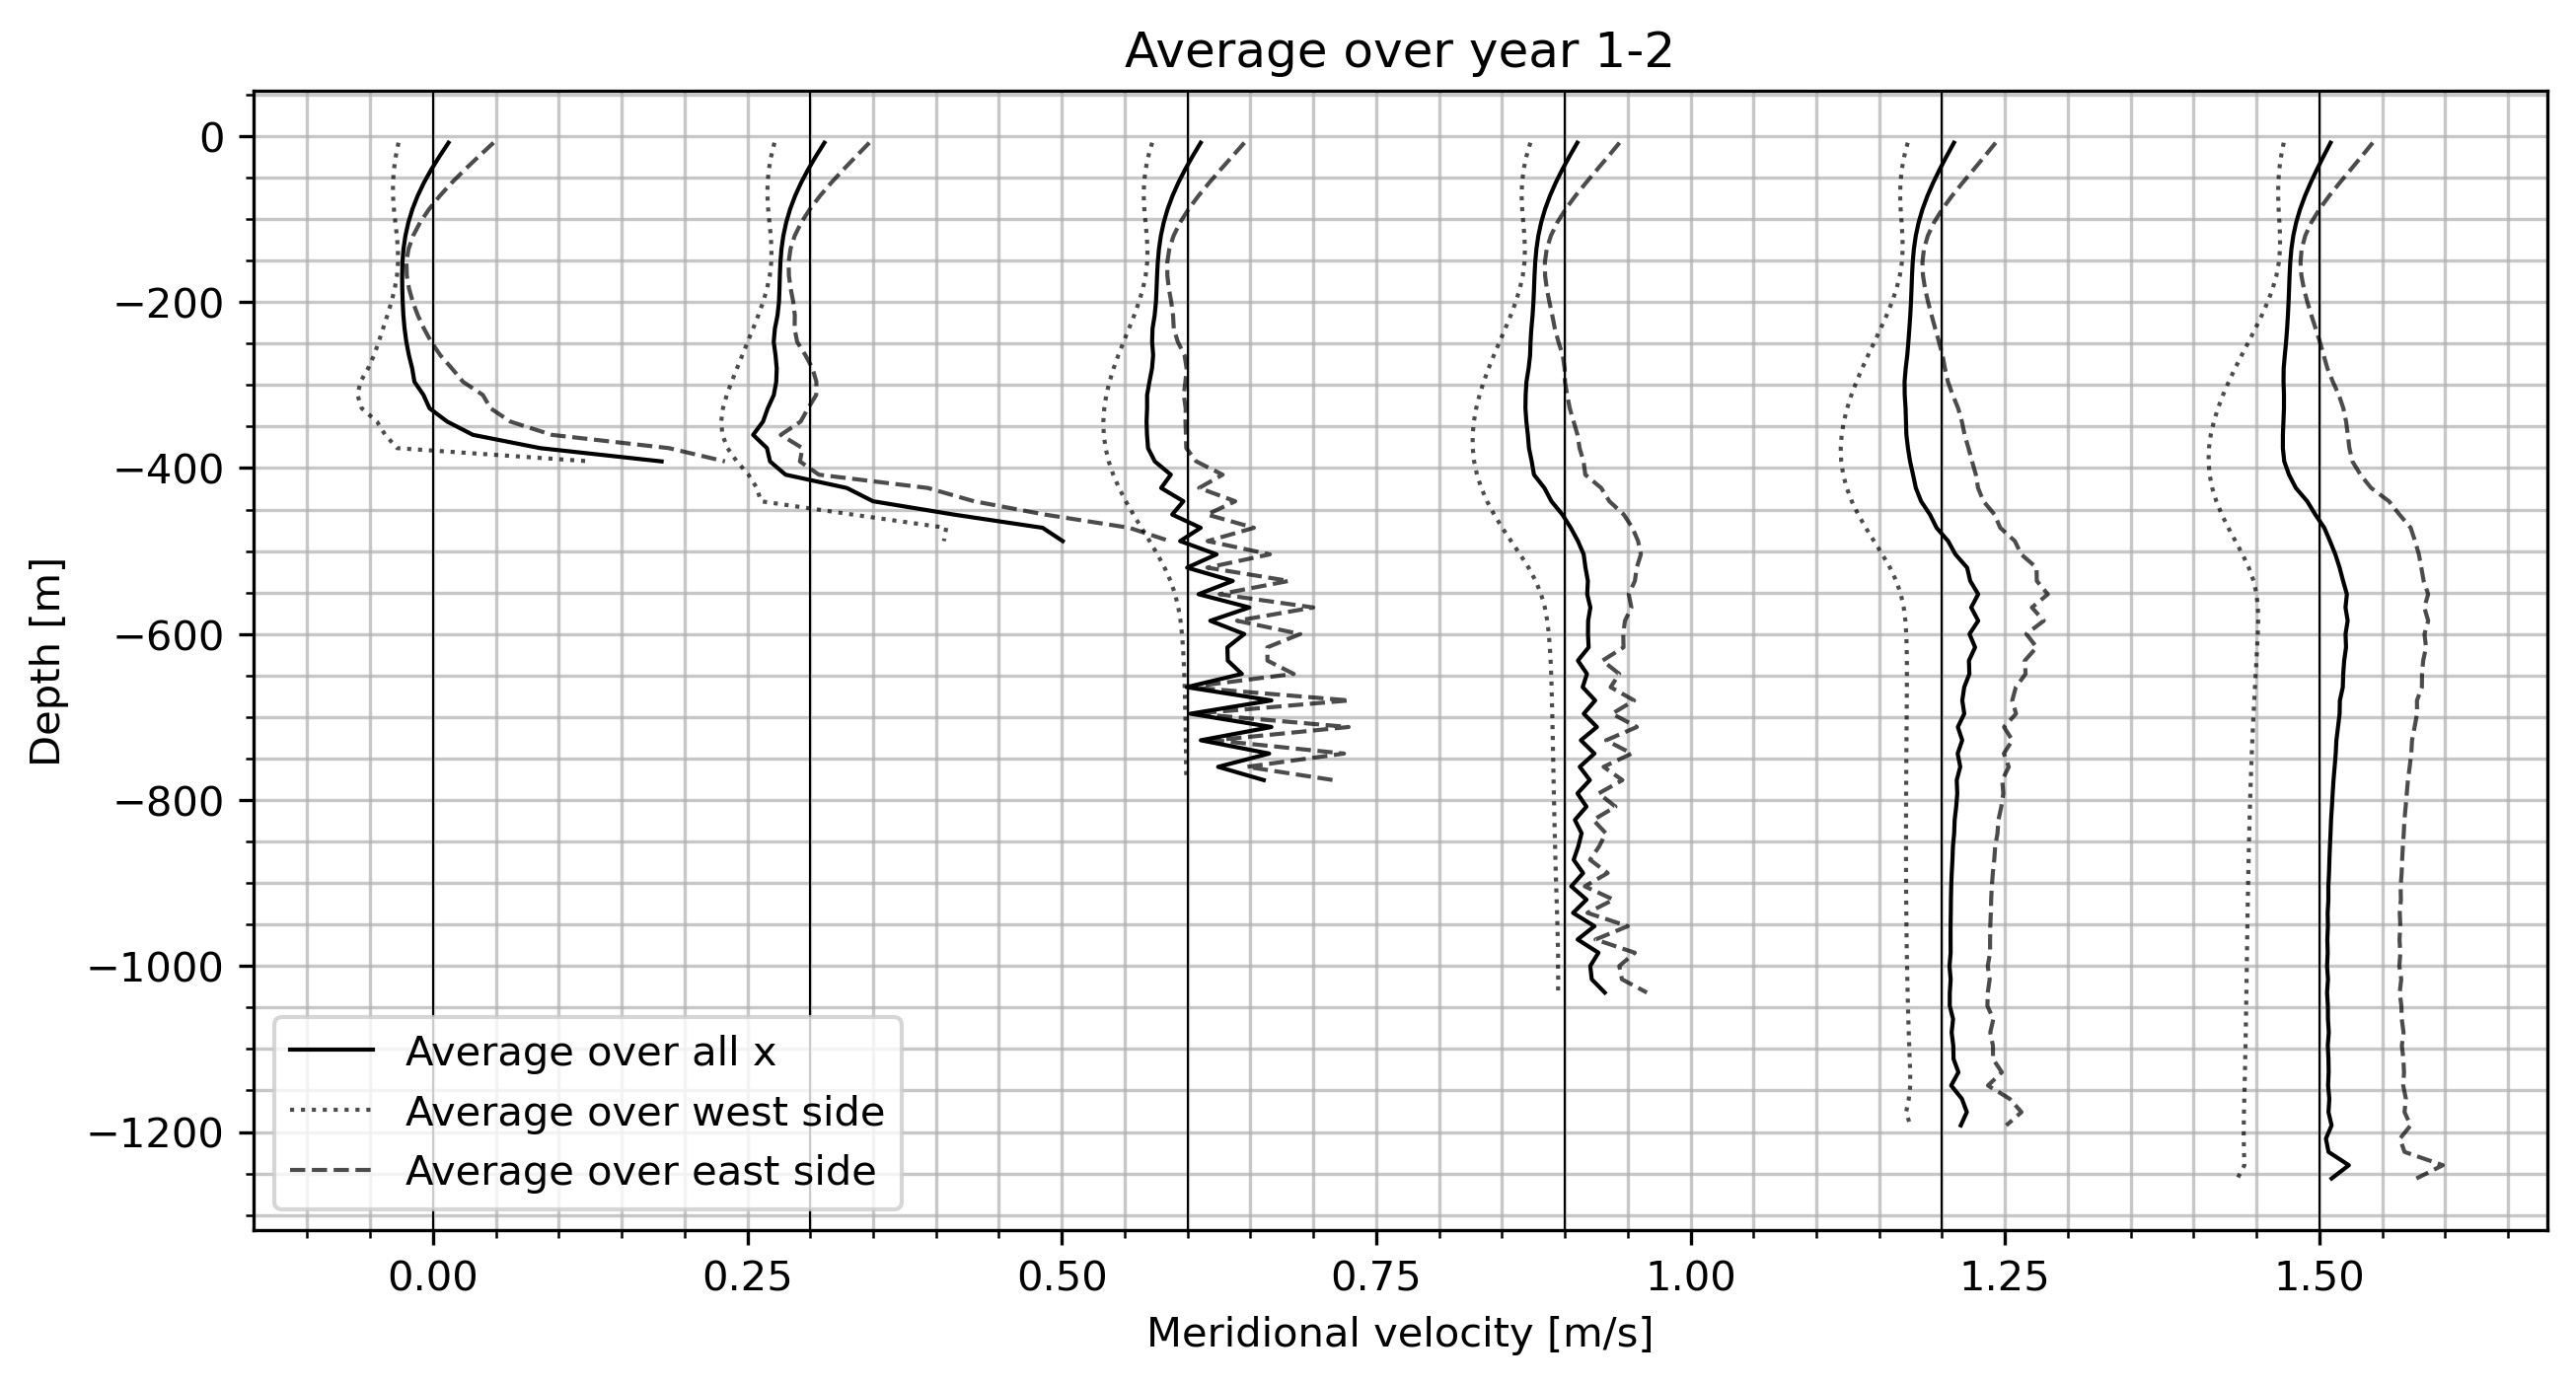

In [8]:

fig,ax=plt.subplots()
p=0
for line in lines:
    ax.plot(np.mean(np.ma.masked_array(np.mean(ds.VVEL[start:,:,line,1:-1],axis=0),mask=masks[:,line,1:-1]),axis=1)+0.3*p,dsG.Z,color='black',label='Average over all x',linewidth=1)
    ax.plot(np.mean(np.ma.masked_array(np.mean(ds.VVEL[start:,:,line,1:int(len(dsG.X[1:-1])/2)],axis=0),mask=masks[:,line,1:int(len(dsG.X[1:-1])/2)]),axis=1)+0.3*p,dsG.Z,color='black',alpha=0.7,linewidth=1,linestyle='dotted',label='Average over west side')
    ax.plot(np.mean(np.ma.masked_array(np.mean(ds.VVEL[start:,:,line,int(len(dsG.X[1:-1])/2):-1],axis=0),mask=masks[:,line,int(len(dsG.X[1:-1])/2):-1]),axis=1)+0.3*p,dsG.Z,color='black',alpha=0.7,linewidth=1,linestyle='dashed',label='Average over east side')
    ax.axvline(0.3*p,linewidth=0.5,color='black')
    if p==0:
        ax.legend(loc='lower left')
    p=p+1
ax.minorticks_on()

ax.set(xlabel='Meridional velocity [m/s]',ylabel='Depth [m]',title='Average over year 1-2')

ax.grid(which='both',alpha=0.7)
plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'MeridProfilesUmb2.png', bbox_inches='tight')

In [27]:
avvel[i-1]=np.mean(np.ma.masked_array(np.mean(ds.VVEL[start:,inddep:,umbral+step,i],axis=0),mask=mask[inddep:,umbral+step,i]))

NameError: name 'inddep' is not defined

In [19]:
alpha=2*1e-4
RHO=np.zeros(np.shape(ds.THETA.values))
for i in range(len(ds.T)):
    tempIn=np.full(shape=np.shape(ds.THETA[i].values), fill_value=np.nan)
    tempIn[np.where(mask==False)]=ds.THETA[i].values[np.where(mask==False)]
    RHO[i,:,:,:]=999.8*(1-(tempIn-14)*alpha)

In [20]:
drho=np.zeros(np.shape(ds.THETA[:,1:,:,:].values))
rhoprof=np.zeros(np.shape(ds.THETA[:,1:,:,:].values))
for i in range(len(ds.T)):
    drho[i]=(RHO[i,1:,:,:]-RHO[i,:-1,:,:])/(dsG.Z.values[None,1:,None,None]-dsG.Z.values[None,:-1,None,None])
    rhoprof[i]=(RHO[i,1:,:,:]+RHO[i,:-1,:,:])/2
g=9.81
Nf2=-(g/rhoprof)*drho
Nf2[Nf2<0]=np.nan
Nf=np.nanmean(np.sqrt(Nf2),axis=1)

zf=(dsG.Z[1:].values+dsG.Z[:-1].values)/2

/var/folders/fl/w6vkfnfn7c17jtg6gqg_hb0w0000gn/T/ipykernel_26494/3175851444.py:9: RuntimeWarning: Mean of empty slice
  Nf=np.nanmean(np.sqrt(Nf2),axis=1)


In [9]:
H=dsG.Depth.values

In [10]:
Cn = Nf*H[None,:,:]/np.pi
Cn[Cn==0]=np.nan

In [176]:
H1

<xarray.DataArray 'Z' ()> Size: 8B
array(184.)
Coordinates:
    Z        float64 8B -184.0

### Rossby radius as $ L_D=\frac{\sqrt{g'H_{2}}}{f}$  with $g'=g \frac{\rho_{2}-\rho_{1}}{\rho_{mean}}$

In [11]:
lat=(22.92+31.70)/2

omega=7.2921*(10**(-5))

f=2*omega*sin(np.deg2rad(lat))

In [21]:
inddeprho1=0
inddeprho2=np.where(np.mean(ds.VVEL[start:,:,umbral1,38],axis=0)<0)[0][-1]
inddepBot=np.argmin(np.ma.masked_array(dsG.Z.values,mask=mask[:,umbral1,20]))
rho1=np.mean(np.ma.masked_array(np.mean(RHO[start:,inddeprho1:inddeprho2,umbral1,OBendx-1],axis=0),mask=mask[inddeprho1:inddeprho2,umbral1,OBendx-1]))
rho2=np.mean(np.ma.masked_array(np.mean(RHO[start:,inddeprho2:inddepBot,umbral1,OBendx-1],axis=0),mask=mask[inddeprho2:inddepBot,umbral1,OBendx-1]))
gprime=9.81*(rho2-rho1)/999.8

H2=dsG.Z[inddeprho2]-np.min(np.ma.masked_array(dsG.Z.values,mask=mask[:,umbral1,10]))

Ro=np.sqrt(gprime*H2)/f

In [22]:
print(Ro.values)

12272.004344087627


In [23]:
rho2

np.float64(1000.0720269576245)

### Rossby radius as $ L_D=\frac{\sqrt{\frac{g'H_{1}H_{2}}{H_{1}+H_{2}}}}{f}$  with $g'=g \frac{\rho_{2}-\rho_{1}}{\rho_{mean}}$

In [41]:
lat=(22.92+31.70)/2

omega=7.2921*(10**(-5))

f=2*omega*sin(np.deg2rad(lat))

In [42]:
inddeprho1=0
inddeprho2=np.where(np.mean(ds.VVEL[start:,:,umbral2,38],axis=0)<0)[0][-1]
inddepBot=np.argmin(np.ma.masked_array(dsG.Z.values,mask=mask[:,umbral2,10]))
rho1=np.mean(np.ma.masked_array(np.mean(RHO[start:,inddeprho1:inddeprho2,umbral2,OBendx-1],axis=0),mask=mask[inddeprho1:inddeprho2,umbral2,OBendx-1]))
rho2=np.mean(np.ma.masked_array(np.mean(RHO[start:,inddeprho2:inddepBot,umbral2,OBendx-1],axis=0),mask=mask[inddeprho2:inddepBot,umbral2,OBendx-1]))
gprime=9.81*(rho2-rho1)/999.8

H2=dsG.Z[inddeprho2]-np.min(np.ma.masked_array(dsG.Z.values,mask=mask[:,umbral2,10]))
H1=0-dsG.Z[inddeprho2]


Ro=np.sqrt((gprime*H1*H2)/(H1+H2))/f

In [25]:
print(Ro.values)

9542.349965508292


In [45]:
H2+H1

<xarray.DataArray 'Z' ()> Size: 8B
array(600.)
Coordinates:
    Z        float64 8B -408.0

### Rossby radius as $ L_D=\frac{\bar{N}H}{\pi f}$  

In [28]:
Nro=np.mean(Nf[start:,umbral2,OBendx-1],axis=0)
Hro=-np.min(np.ma.masked_array(dsG.Z.values,mask=mask[:,umbral2,10]))

print((Nro*Hro)/(np.pi*f))

8322.749550743247


In [48]:
#transps=[]
#depths=[]
#avvels=[]
#for step in np.arange(0,50,10):

umb=umbral2
umbEnd=umbralEnd2
depth=np.zeros((len(dsG.Y[umb:umbEnd]),len(dsG.X[1:-1])))
avvel=np.zeros((len(dsG.Y[umb:umbEnd]),len(dsG.X[1:-1])))
transp=np.zeros((len(dsG.Y[umb:umbEnd]),len(dsG.X[1:-1])))
k=0
for p in np.arange(umb,umbEnd,1):
    for i in np.arange(1,len(dsG.X)-1,1):
        if np.any(np.mean(ds.VVEL[start:,:,p,i],axis=0)<0)==False:
            inddep=np.argmax(np.mean(ds.VVEL[start:,:,p,i].values,axis=0))-6
            depth[k,i-1]=dsG.Z[inddep]
            avvel[k,i-1]=np.mean(np.ma.masked_array(np.mean(ds.VVEL[start:,:,p,i],axis=0),mask=mask[:,p,i]))
        else:
            inddep=np.where(np.mean(ds.VVEL[start:,:,p,i],axis=0)<0)[0][-1]
            depth[k,i-1]=dsG.Z[inddep]
            avvel[k,i-1]=np.mean(np.ma.masked_array(np.mean(ds.VVEL[start:,inddep:,p,i],axis=0),mask=mask[inddep:,p,i]))
            maxdep=np.min(np.ma.masked_array(dsG.Z.values,mask=mask[:,p,i]))
            transp[k,i-1]=np.sum((depth[k,i-1]-maxdep)*(dsG.Xp1[i]-dsG.Xp1[i-1])*avvel[k,i-1]*1e-6)
    k=k+1


transport

In [49]:
np.sum(transp[0])

np.float64(0.17228340047083154)

maxvel

In [116]:
np.max(avvel[0])

np.float64(0.20123718678951263)

thickness of current

In [130]:
(depth[0]+600)[-1]

np.float64(192.0)

Width of current

In [128]:
dsG.X[np.where(depth[0]+600>50)][0]-dsG.X[np.where(depth[0]+600>50)][-1]

<xarray.DataArray 'X' ()> Size: 8B
array(-18000.)

In [29]:
params = {'font.size': 15,
          'figure.figsize': (12, 5),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [129]:
depth[p]+600

array([ 48.,  64.,  64.,  64.,  80.,  80.,  96.,  96.,  96., 112., 112.,
       112., 112., 128., 128., 128., 128., 128., 128., 128., 128., 144.,
       144., 144., 144., 144., 160., 160., 160., 160., 160., 176., 176.,
       176., 176., 192., 192., 192.])

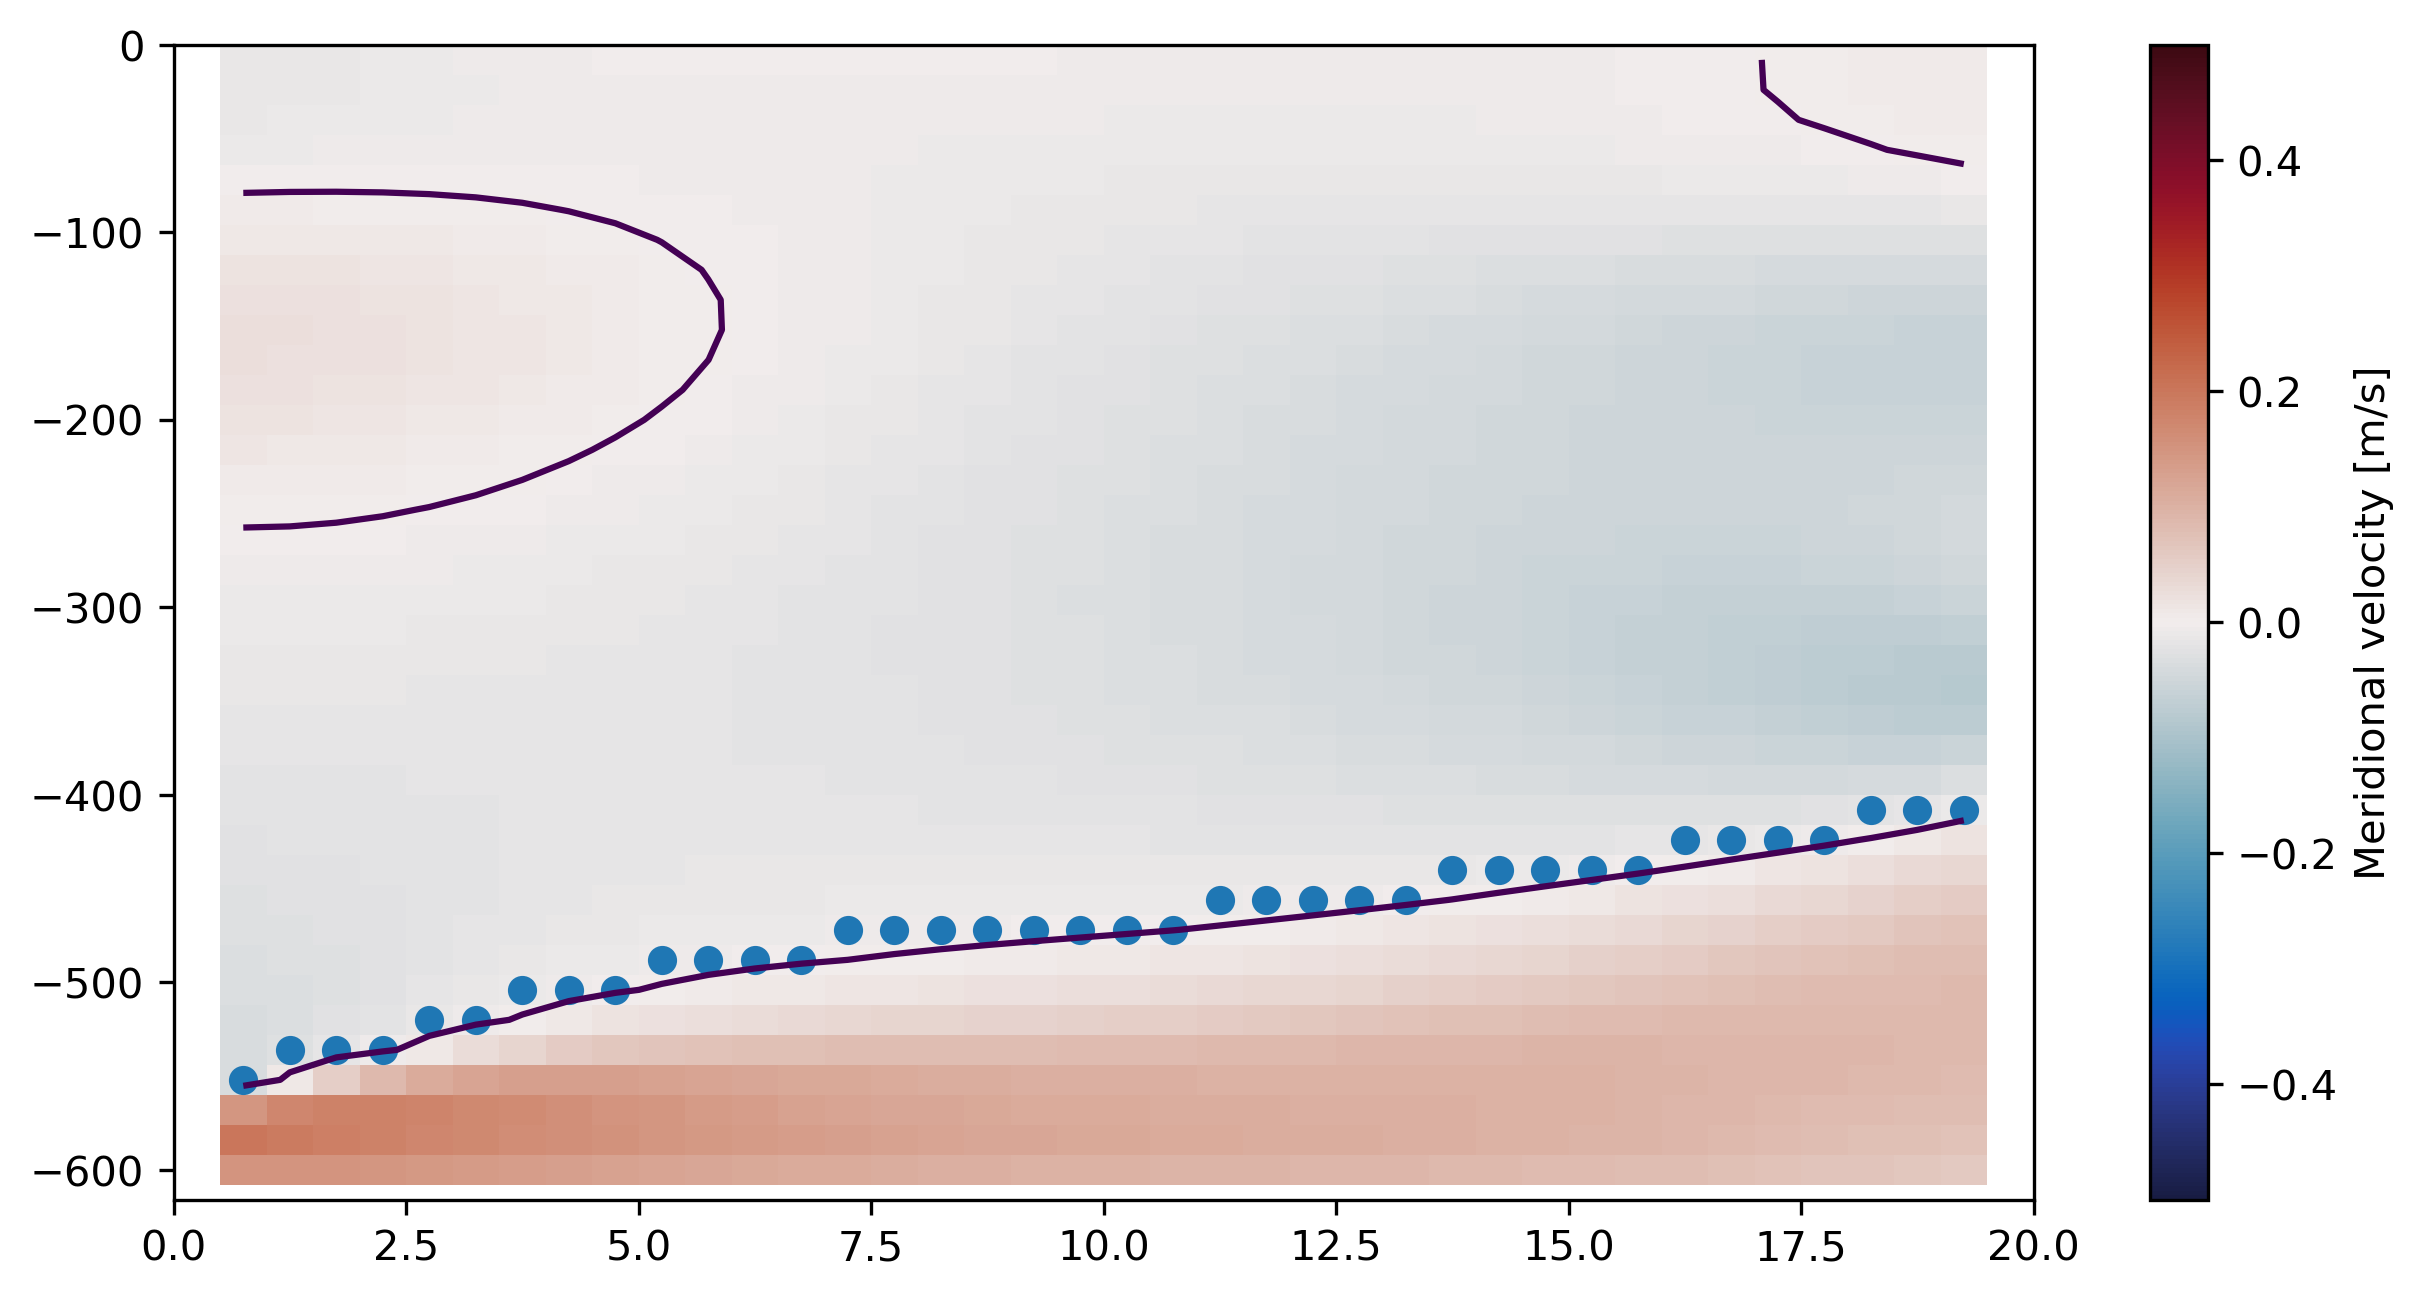

In [125]:
indy=np.arange(umbral2,umbralEnd2,1)
p=0 #np.arange(0,50,10)[0]

cax=plt.pcolormesh(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VVEL[start:,:,indy[p],:],axis=0),mask=mask[:,indy[p],:]),vmin=-0.5,vmax=0.5,cmap=cmocean.cm.balance)
ymax=dsG.Z.values[mask[:,indy[p],5]==True][0]
plt.ylim((ymax,0))
plt.scatter(dsG.X[1:-1]/1000,depth[p])
cbar=plt.colorbar(cax)
cbar.set_label('Meridional velocity [m/s]')
plt.contour(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VVEL[start:,:,indy[p],:],axis=0),mask=mask[:,indy[p],:]),levels=[0])

#plt.text(dsG.X[27]/1000, dsG.Z[11], f' {np.sum(transp[p,int(len(dsG.X[1:-1])/2):]):.2g} SV\non east side', color='k',fontsize=8)
#plt.text(dsG.X[5]/1000, dsG.Z[11], f' {np.sum(transp[p,:int(len(dsG.X[1:-1])/2)]):.2g} SV\non west side', color='k',fontsize=8)
#plt.text(dsG.X[17]/1000, dsG.Z[10], f' {np.sum(transp[p]):.2g} SV\nin total', color='k',fontsize=8)

#plt.text(dsG.X[5]-2000, -200, f'Total transport\n{np.sum((dsG.Z[siz]-ymax)*2000*vel*1e-6):.1g} SV', color='k',fontsize=8)

#plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'MeridTransportSillTop.png', bbox_inches='tight')

In [36]:
alpha=2*1e-4
RHO=np.zeros(np.shape(ds.THETA.values))
for i in range(len(ds.T)):
    RHO[i,:,:,:]=999.8*(1-np.ma.masked_array(ds.THETA[i].values-14,mask=mask)*alpha)

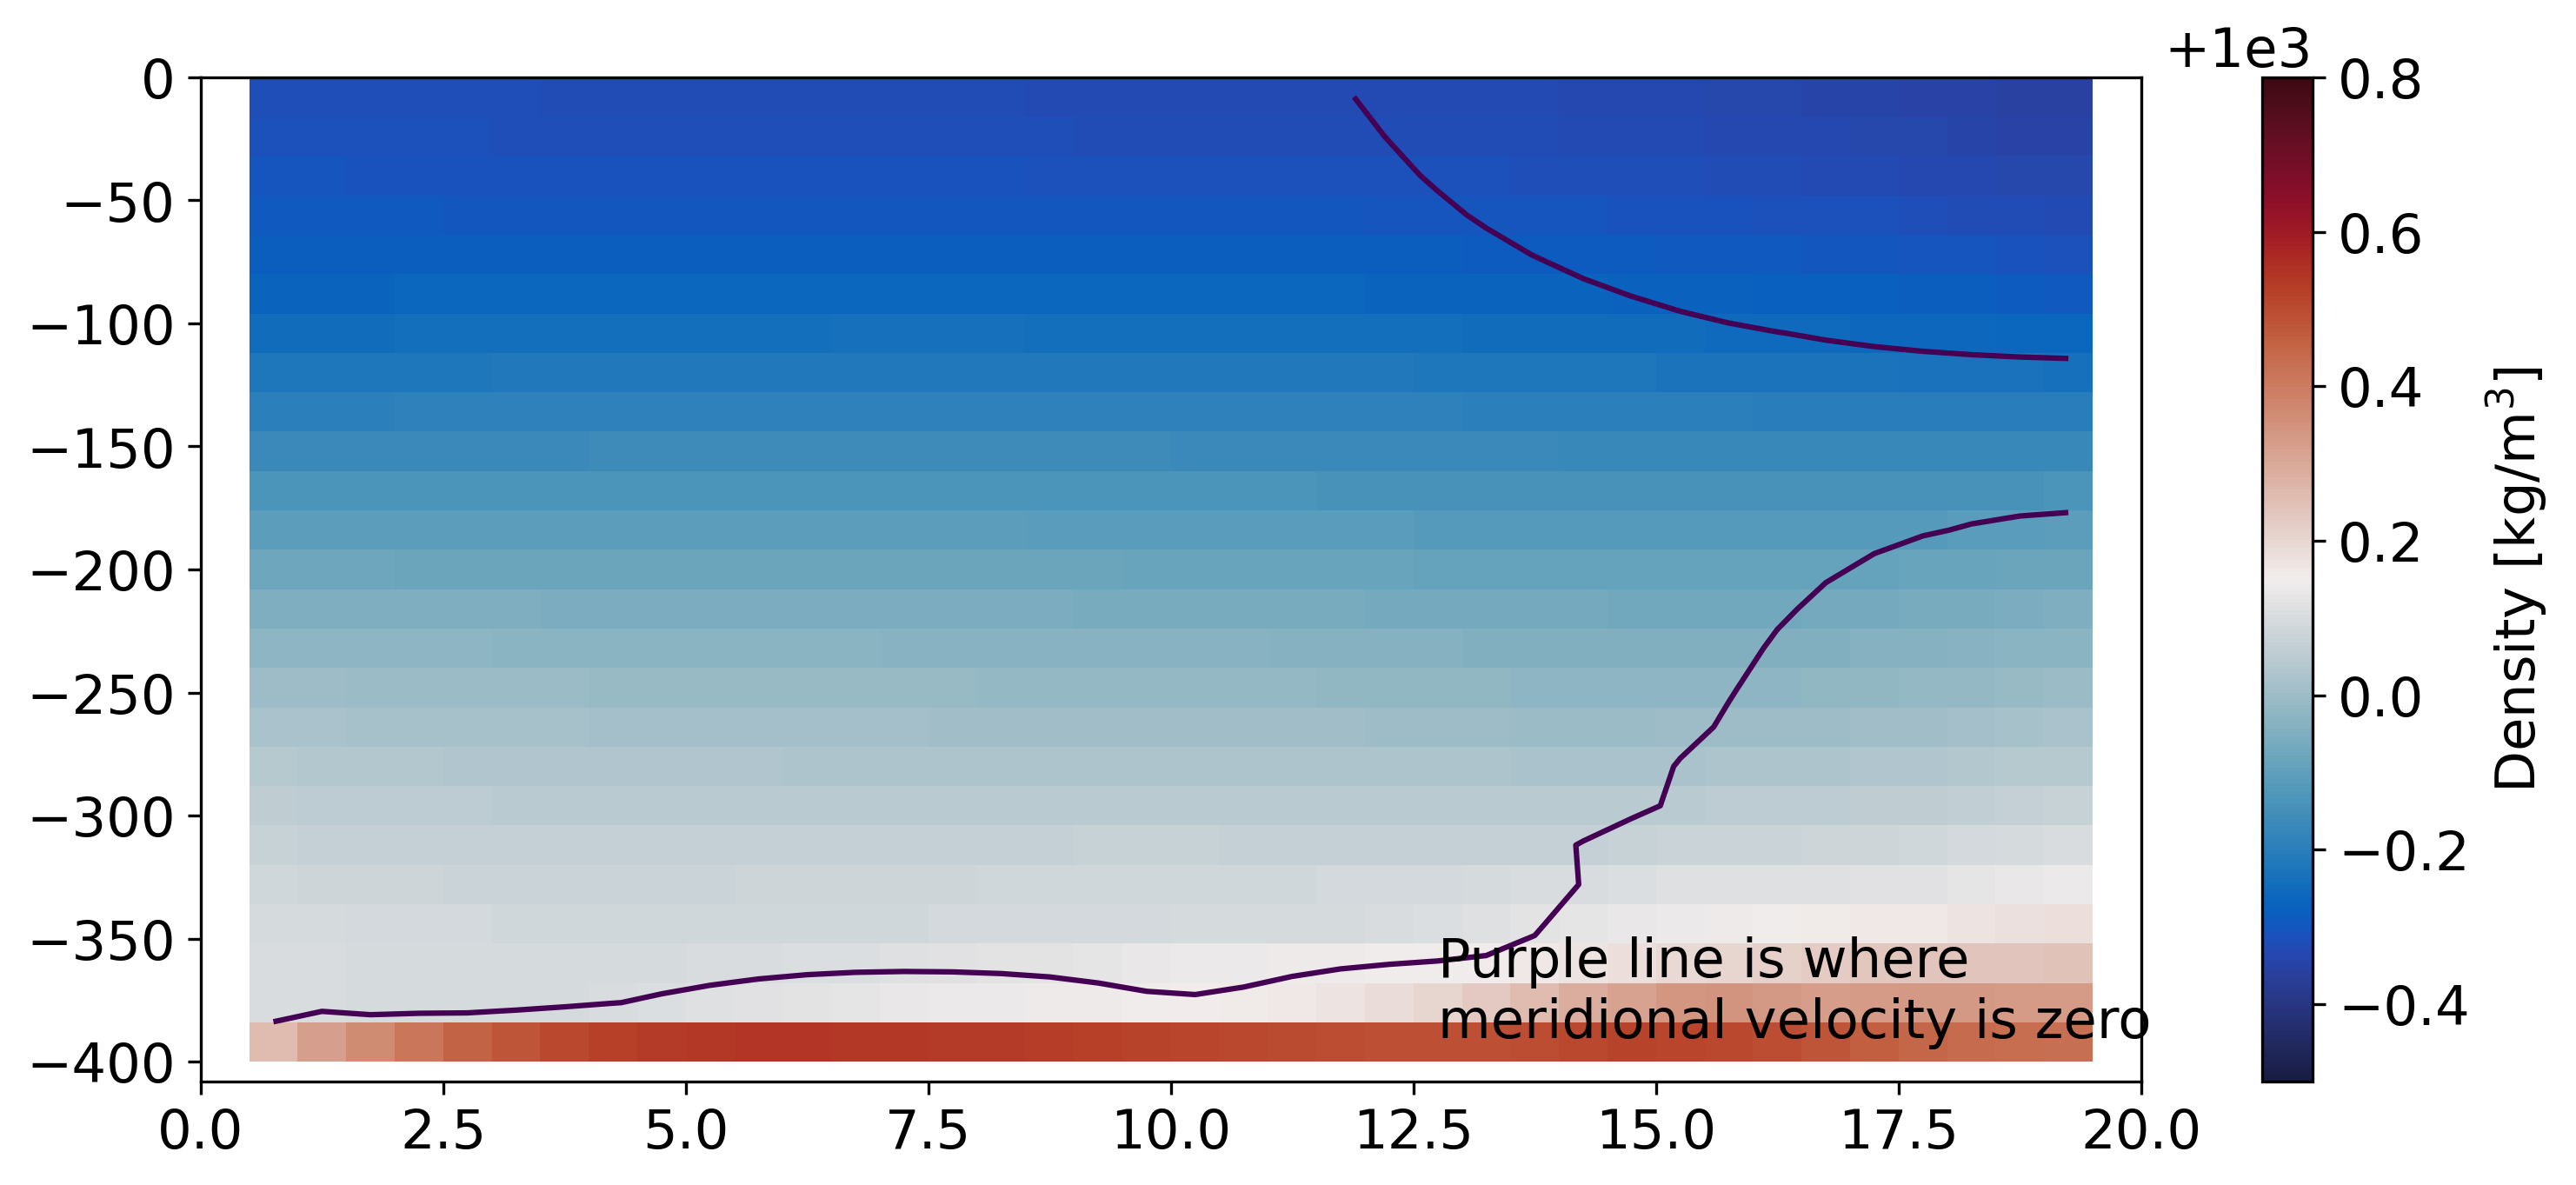

In [37]:
vmin=np.min(np.ma.masked_array(np.mean(RHO[start:,:,umbral,:],axis=0),mask=mask[:,umbral,:]))
vmax=-np.min(np.ma.masked_array(np.mean(RHO[start:,:,umbral,:],axis=0),mask=mask[:,umbral,:]))

plt.pcolormesh(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(RHO[start:,:,umbral,:],axis=0),mask=mask[:,umbral,:]),vmin=999.5,vmax=1000.8,cmap=cmocean.cm.balance)
ymax=dsG.Z.values[mask[:,umbral,5]==True][0]
plt.ylim((ymax,0))

cbar=plt.colorbar()
cbar.set_label('Density [kg/m$^{3}$]')
#plt.contour(dsG.X,dsG.Z[:35],ds.VVEL[-1,:35,umbral,:],levels=[0])
plt.contour(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VVEL[start:,:,umbral,:],axis=0),mask=mask[:,umbral,:]),levels=[0])
plt.text(dsG.X[25]/1000, -390, f'Purple line is where\nmeridional velocity is zero', color='k',fontsize=15)
#plt.scatter(dsG.X[1:-1],dsG.Z[siz])
#for i in range(len(siz)):
#    plt.text(dsG.X[1+i]-1000, dsG.Z[siz[i]]+40, f' {((dsG.Z[siz[i]]-ymax)*2000*vel[i]*1e-6):.1g} SV', color='k',fontsize=8)

#plt.text(dsG.X[5]-2000, -200, f'Total transport\n{np.sum((dsG.Z[siz]-ymax)*2000*vel*1e-6):.1g} SV', color='k',fontsize=8)

plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'RhoTransport.png', bbox_inches='tight')

In [39]:
params = {'font.size': 15,
          'figure.figsize': (10, 10),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [40]:
np.min(np.ma.masked_array(np.mean(ds.THETA[start:,:,umbral1,OBx:OBendx],axis=0),mask=mask[:,umbral1,OBx:OBendx]))

np.float32(6.4842377)

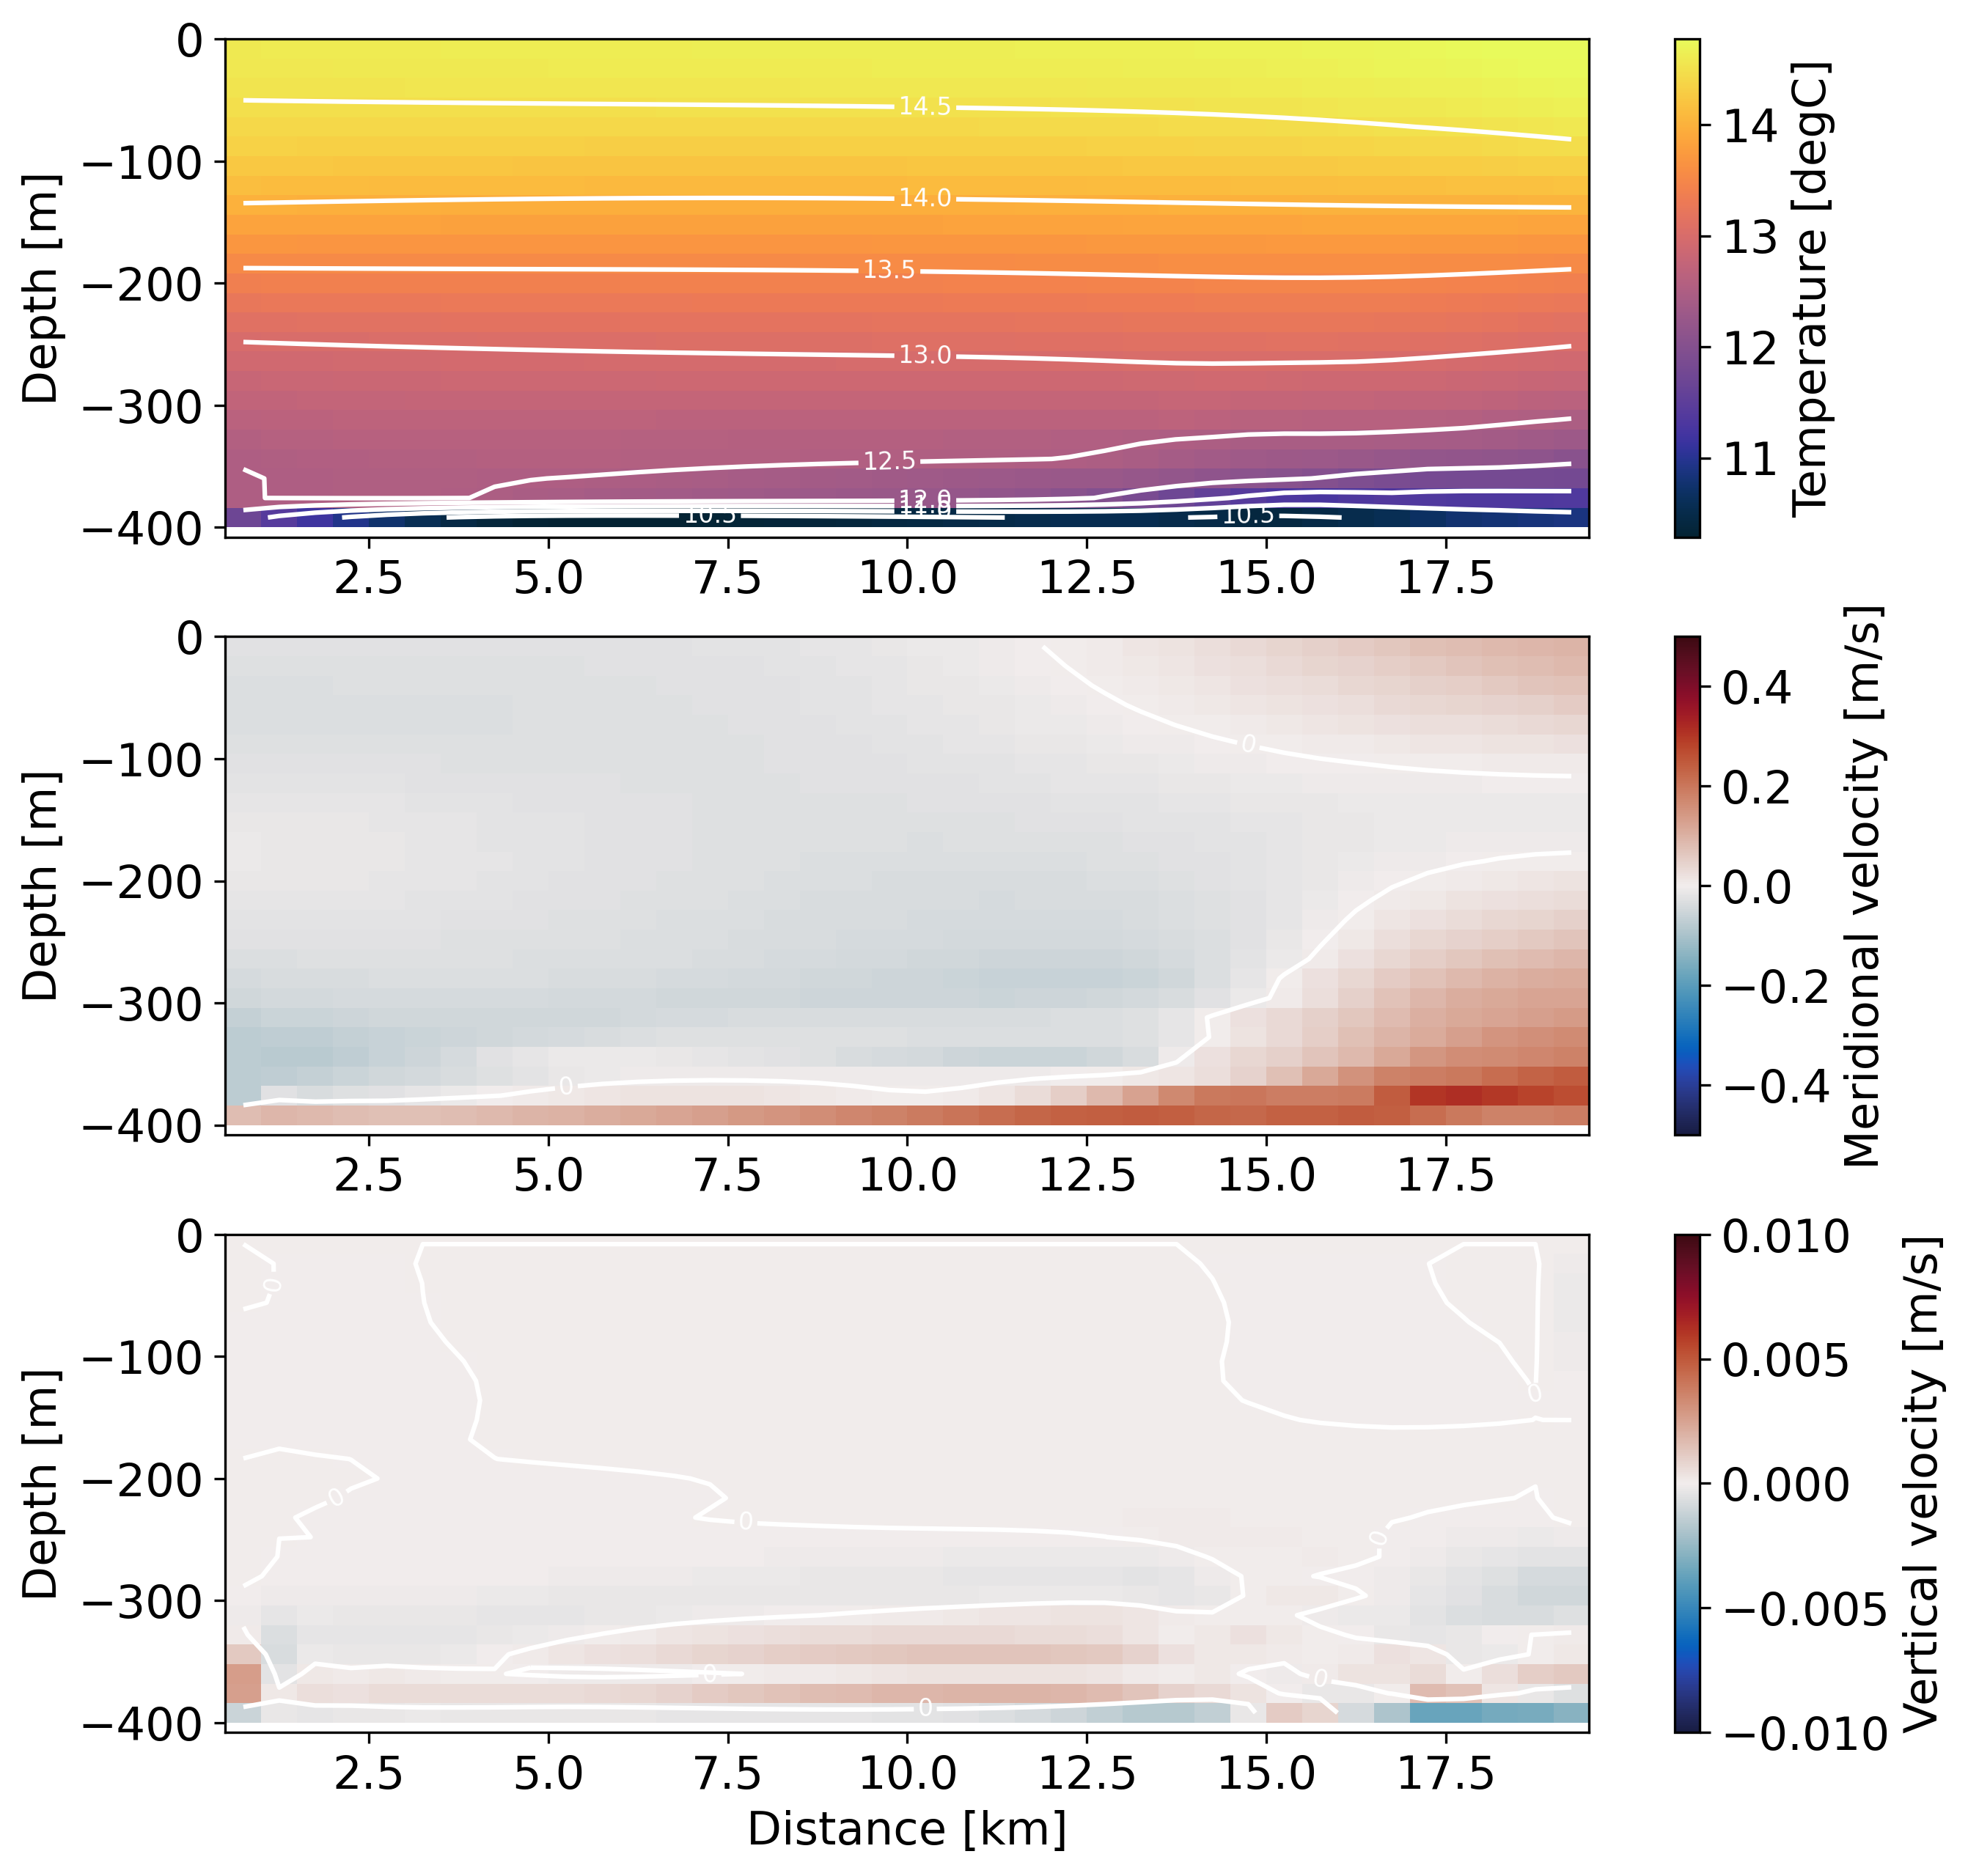

In [41]:
indy=np.arange(umbral,umbralEnd,1)
p=0 #np.arange(0,50,10)[0]

fig,axin = plt.subplots(3)

ax=axin[0]

vmin=np.nanmin(np.ma.masked_array(np.mean(ds.THETA[start:,:,indy[p],:],axis=0),mask=mask[:,indy[p],:]))
vmax=np.nanmax(np.ma.masked_array(np.mean(ds.THETA[start:,:,indy[p],:],axis=0),mask=mask[:,indy[p],:]))

cax=ax.pcolormesh(dsG.X[OBx:OBendx]/1000,dsG.Z,np.ma.masked_array(np.mean(ds.THETA[start:,:,indy[p],OBx:OBendx],axis=0),mask=mask[:,indy[p],OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmocean.cm.thermal)
ymax=dsG.Z.values[mask[:,indy[p],5]==True][0]
ax.set_ylim((ymax,0))

levels=np.arange(10,15,0.5) #[14.9,14.95,15,15.5,16,17,18]
cbar=plt.colorbar(cax)
cbar.set_label('Temperature [degC]')
caxC=ax.contour(dsG.X[OBx:OBendx]/1000,dsG.Z,np.ma.masked_array(np.mean(ds.THETA[start:,:,indy[p],OBx:OBendx],axis=0),mask=masks[:,indy[p],OBx:OBendx]),levels=levels,colors='white')
ax.clabel(caxC, inline=1, fontsize=8)
ax.set(ylabel='Depth [m]')
ax=axin[1]

cax=ax.pcolormesh(dsG.X[OBx:OBendx]/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VVEL[start:,:,indy[p],OBx:OBendx],axis=0),mask=masks[:,indy[p],OBx:OBendx]),vmin=-0.5,vmax=0.5,cmap=cmocean.cm.balance)
ymax=dsG.Z.values[masks[:,indy[p],5]==True][0]
ax.set_ylim((ymax,0))

#ax.axvline(dsG.X[OBx:OBendx][np.where(depth[0]+400<50)[0][-1]]/1000)

cbar=plt.colorbar(cax)
cbar.set_label('Meridional velocity [m/s]')
caxC=ax.contour(dsG.X[OBx:OBendx]/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VVEL[start:,:,indy[p],OBx:OBendx],axis=0),mask=mask[:,indy[p],OBx:OBendx]),levels=[0],colors='white')
ax.clabel(caxC, inline=1, fontsize=8)
ax.set(ylabel='Depth [m]')
ax=axin[2]

cax=ax.pcolormesh(dsG.X[OBx:OBendx]/1000,dsG.Z,np.ma.masked_array(np.mean(ds.WVEL[start:,:,indy[p],OBx:OBendx],axis=0),mask=mask[:,indy[p],OBx:OBendx]),vmin=-0.01,vmax=0.01,cmap=cmocean.cm.balance)
ymax=dsG.Z.values[mask[:,indy[p],5]==True][0]
ax.set_ylim((ymax,0))
ax.set(xlabel='Distance [km]',ylabel='Depth [m]')

cbar=plt.colorbar(cax)
cbar.set_label('Vertical velocity [m/s]')
caxC=ax.contour(dsG.X[OBx:OBendx]/1000,dsG.Z,np.ma.masked_array(np.mean(ds.WVEL[start:,:,indy[p],OBx:OBendx],axis=0),mask=mask[:,indy[p],OBx:OBendx]),levels=[0],colors='white')
ax.clabel(caxC, inline=1, fontsize=8)

plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'SillSectUmb2.png', bbox_inches='tight')

/var/folders/fl/w6vkfnfn7c17jtg6gqg_hb0w0000gn/T/ipykernel_8126/2561169301.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


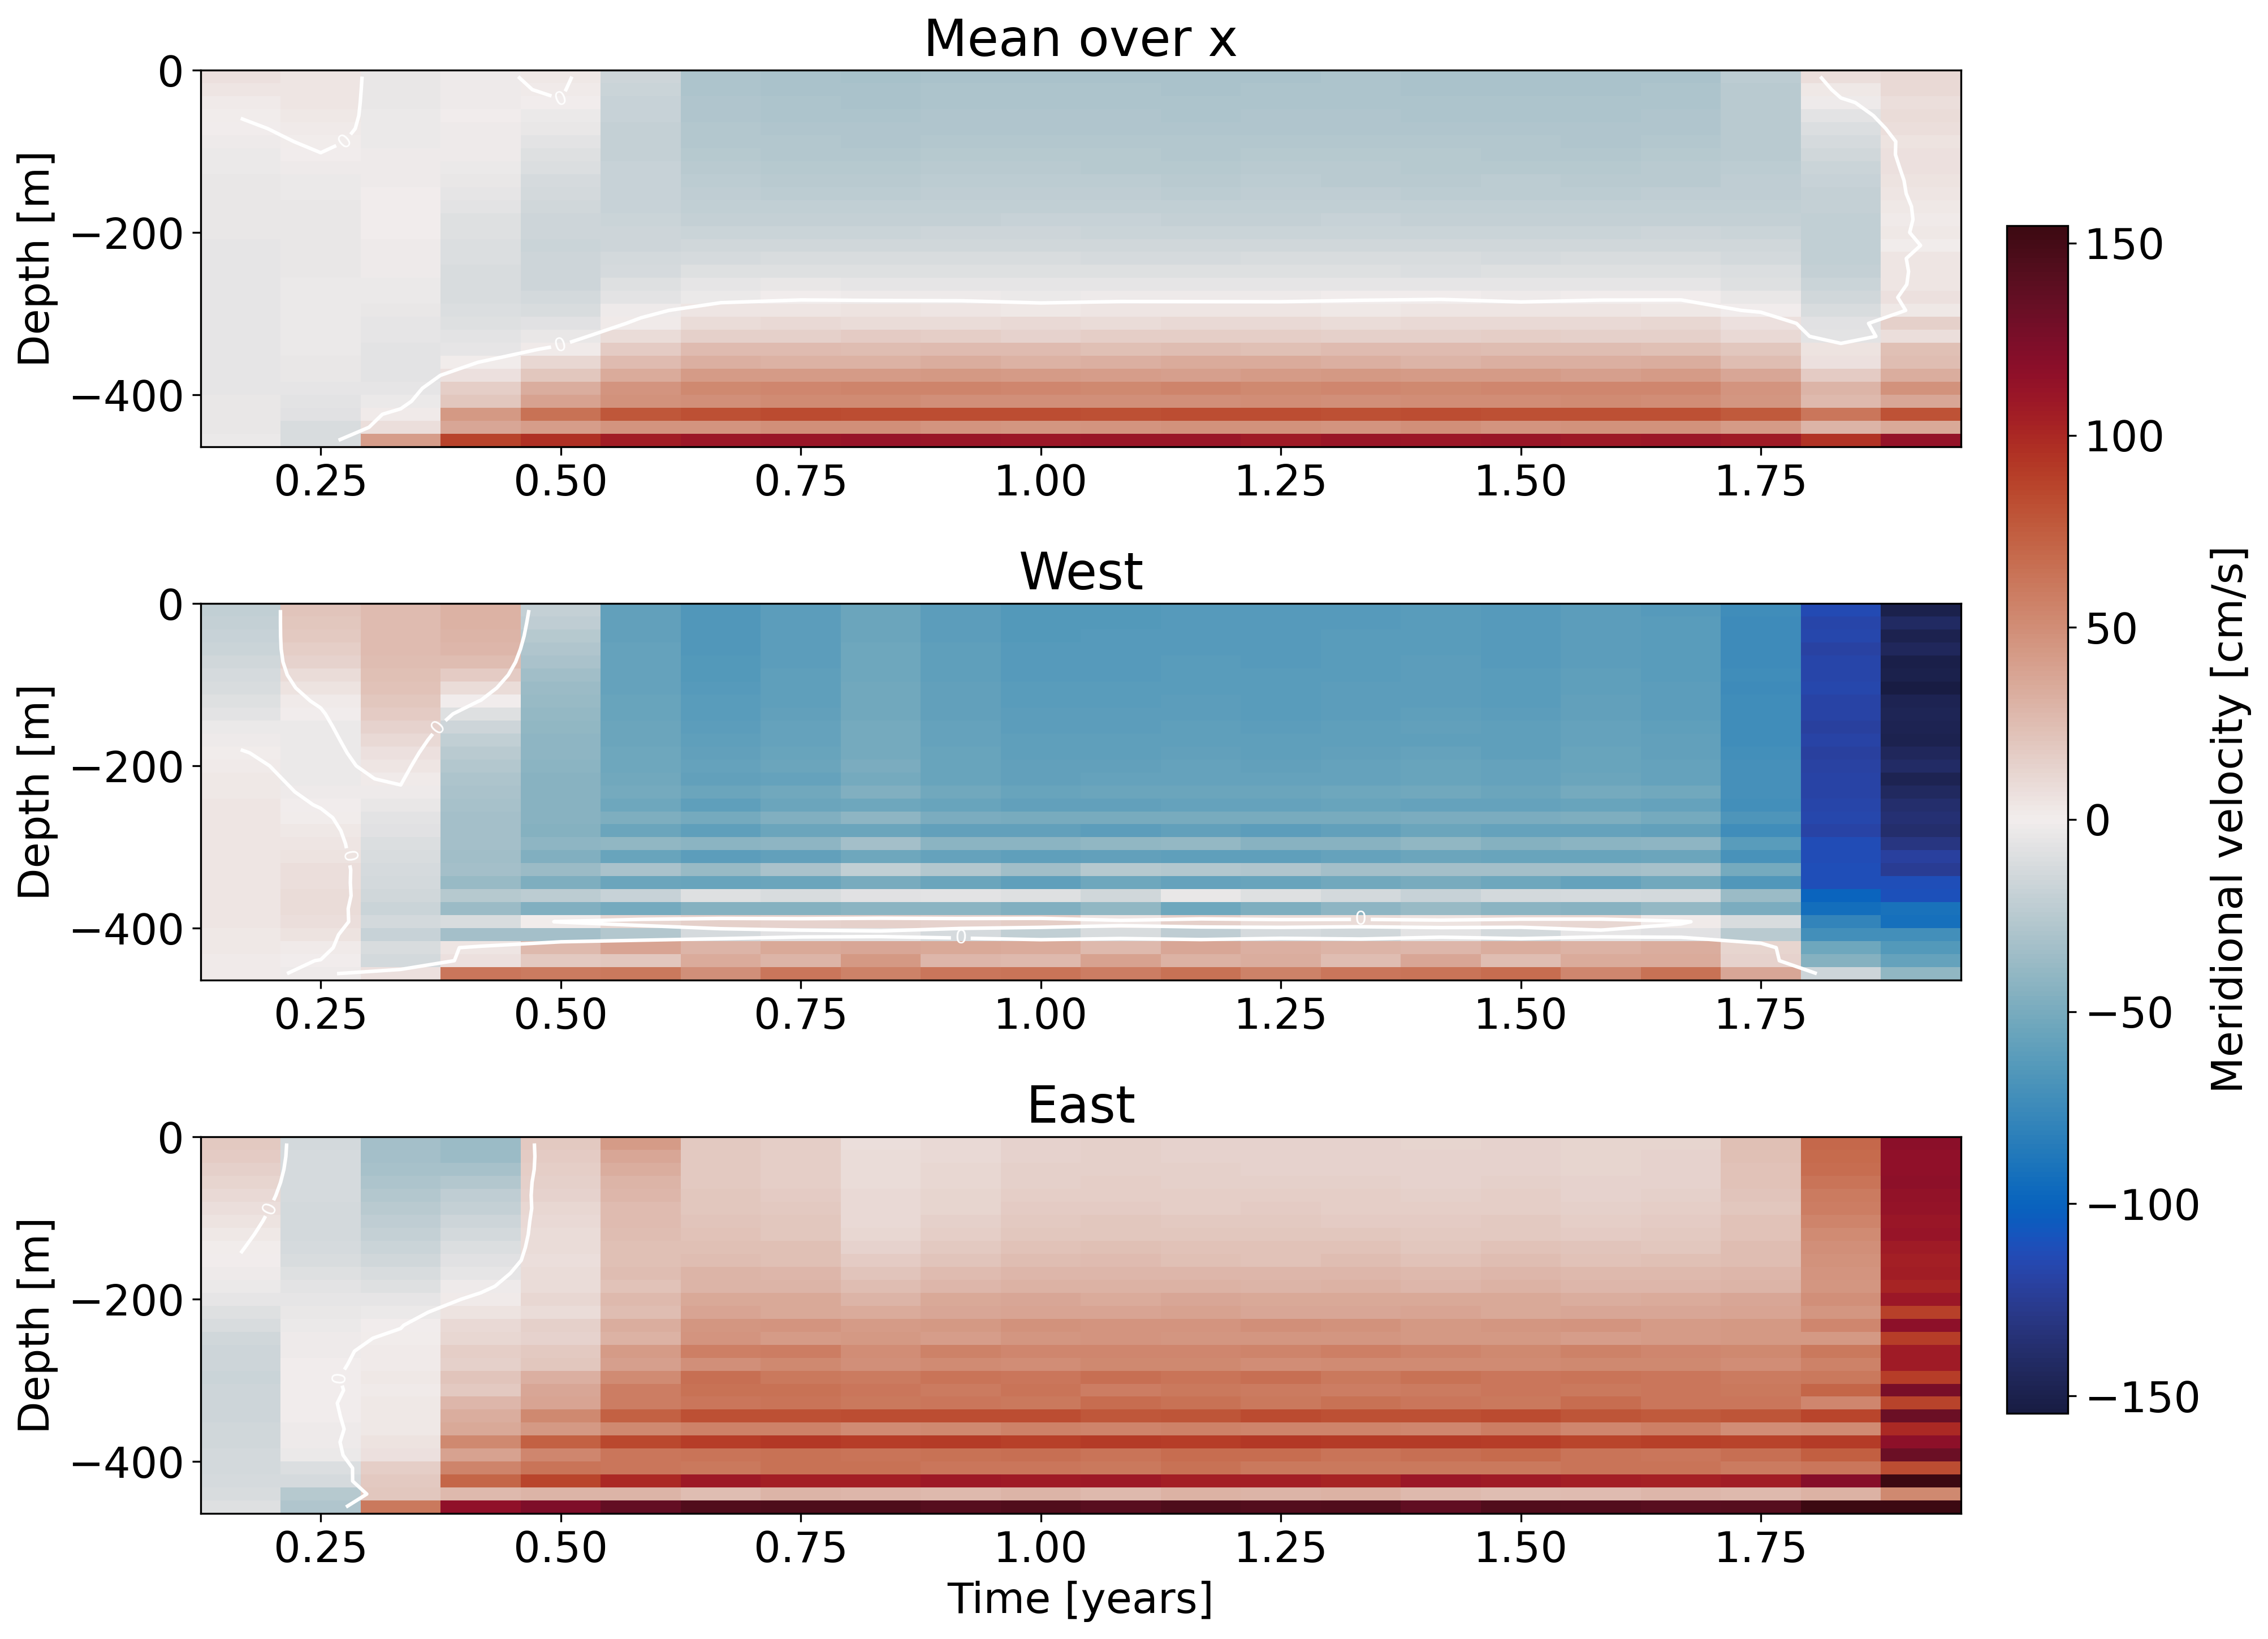

In [78]:
fig,ax = plt.subplots(3)


umb=int(len(dsG.Y)*0.4)
bottom=np.where(ds.THETA[1,:,umb,5].values!=0)[0][-1]


### Temperature ### 
#vmin=11
#vmax=15.2
#step=0.4
#levels=np.arange(vmin,vmax,step)

#cmapi=cmocean.cm.thermal

#val=ds.THETA
#vmin=15
#vmax=18
#levels=[14,14.8,14.95,15,16.5,18]
#clab='Temperature [degC]'


### Velocity ###

val=ds.VVEL*100

vmin=np.min(val[start:end,:bottom,umb,OBx:OBendx])
vmax=-np.min(val[start:end,:bottom,umb,OBx:OBendx])
cmapi=cmocean.cm.balance

levels=[0]
clab='Meridional velocity [cm/s]'


Zin=dsG.Z[:bottom]
timein=ds.T[start:end]/(60*60*24*360)


axin=ax[0]
T=np.mean(val[start:end,:bottom,umb,OBx:OBendx],axis=2)
axin.set(ylabel='Depth [m]',title=f'Mean over x' )
axin.set_facecolor('tan')

cax0=axin.pcolormesh(timein, Zin, T.T,vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(timein, Zin, T.T,levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)

axin=ax[1]
indX=OBx
T=val[start:end,:bottom,umb,indX]
axin.set(ylabel='Depth [m]',title=f'West' )
axin.set_facecolor('tan')

cax0=axin.pcolormesh(timein, Zin, T.T,vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(timein, Zin, T.T,levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)

axin=ax[2]
indX=OBendx-1
T=val[start:end,:bottom,umb,indX]
axin.set(ylabel='Depth [m]',xlabel='Time [years]',title=f'East' )
axin.set_facecolor('tan')

cax0=axin.pcolormesh(timein, Zin, T.T,vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(timein, Zin, T.T,levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)
cbar_ax = fig.add_axes([1, 0.15, 0.03, 0.7])
fig.colorbar(cax0, cax=cbar_ax)
cbar_ax.set_ylabel(clab)

plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'MeridVelHovOnSill.png', bbox_inches='tight')
fig.tight_layout()

## On the sill

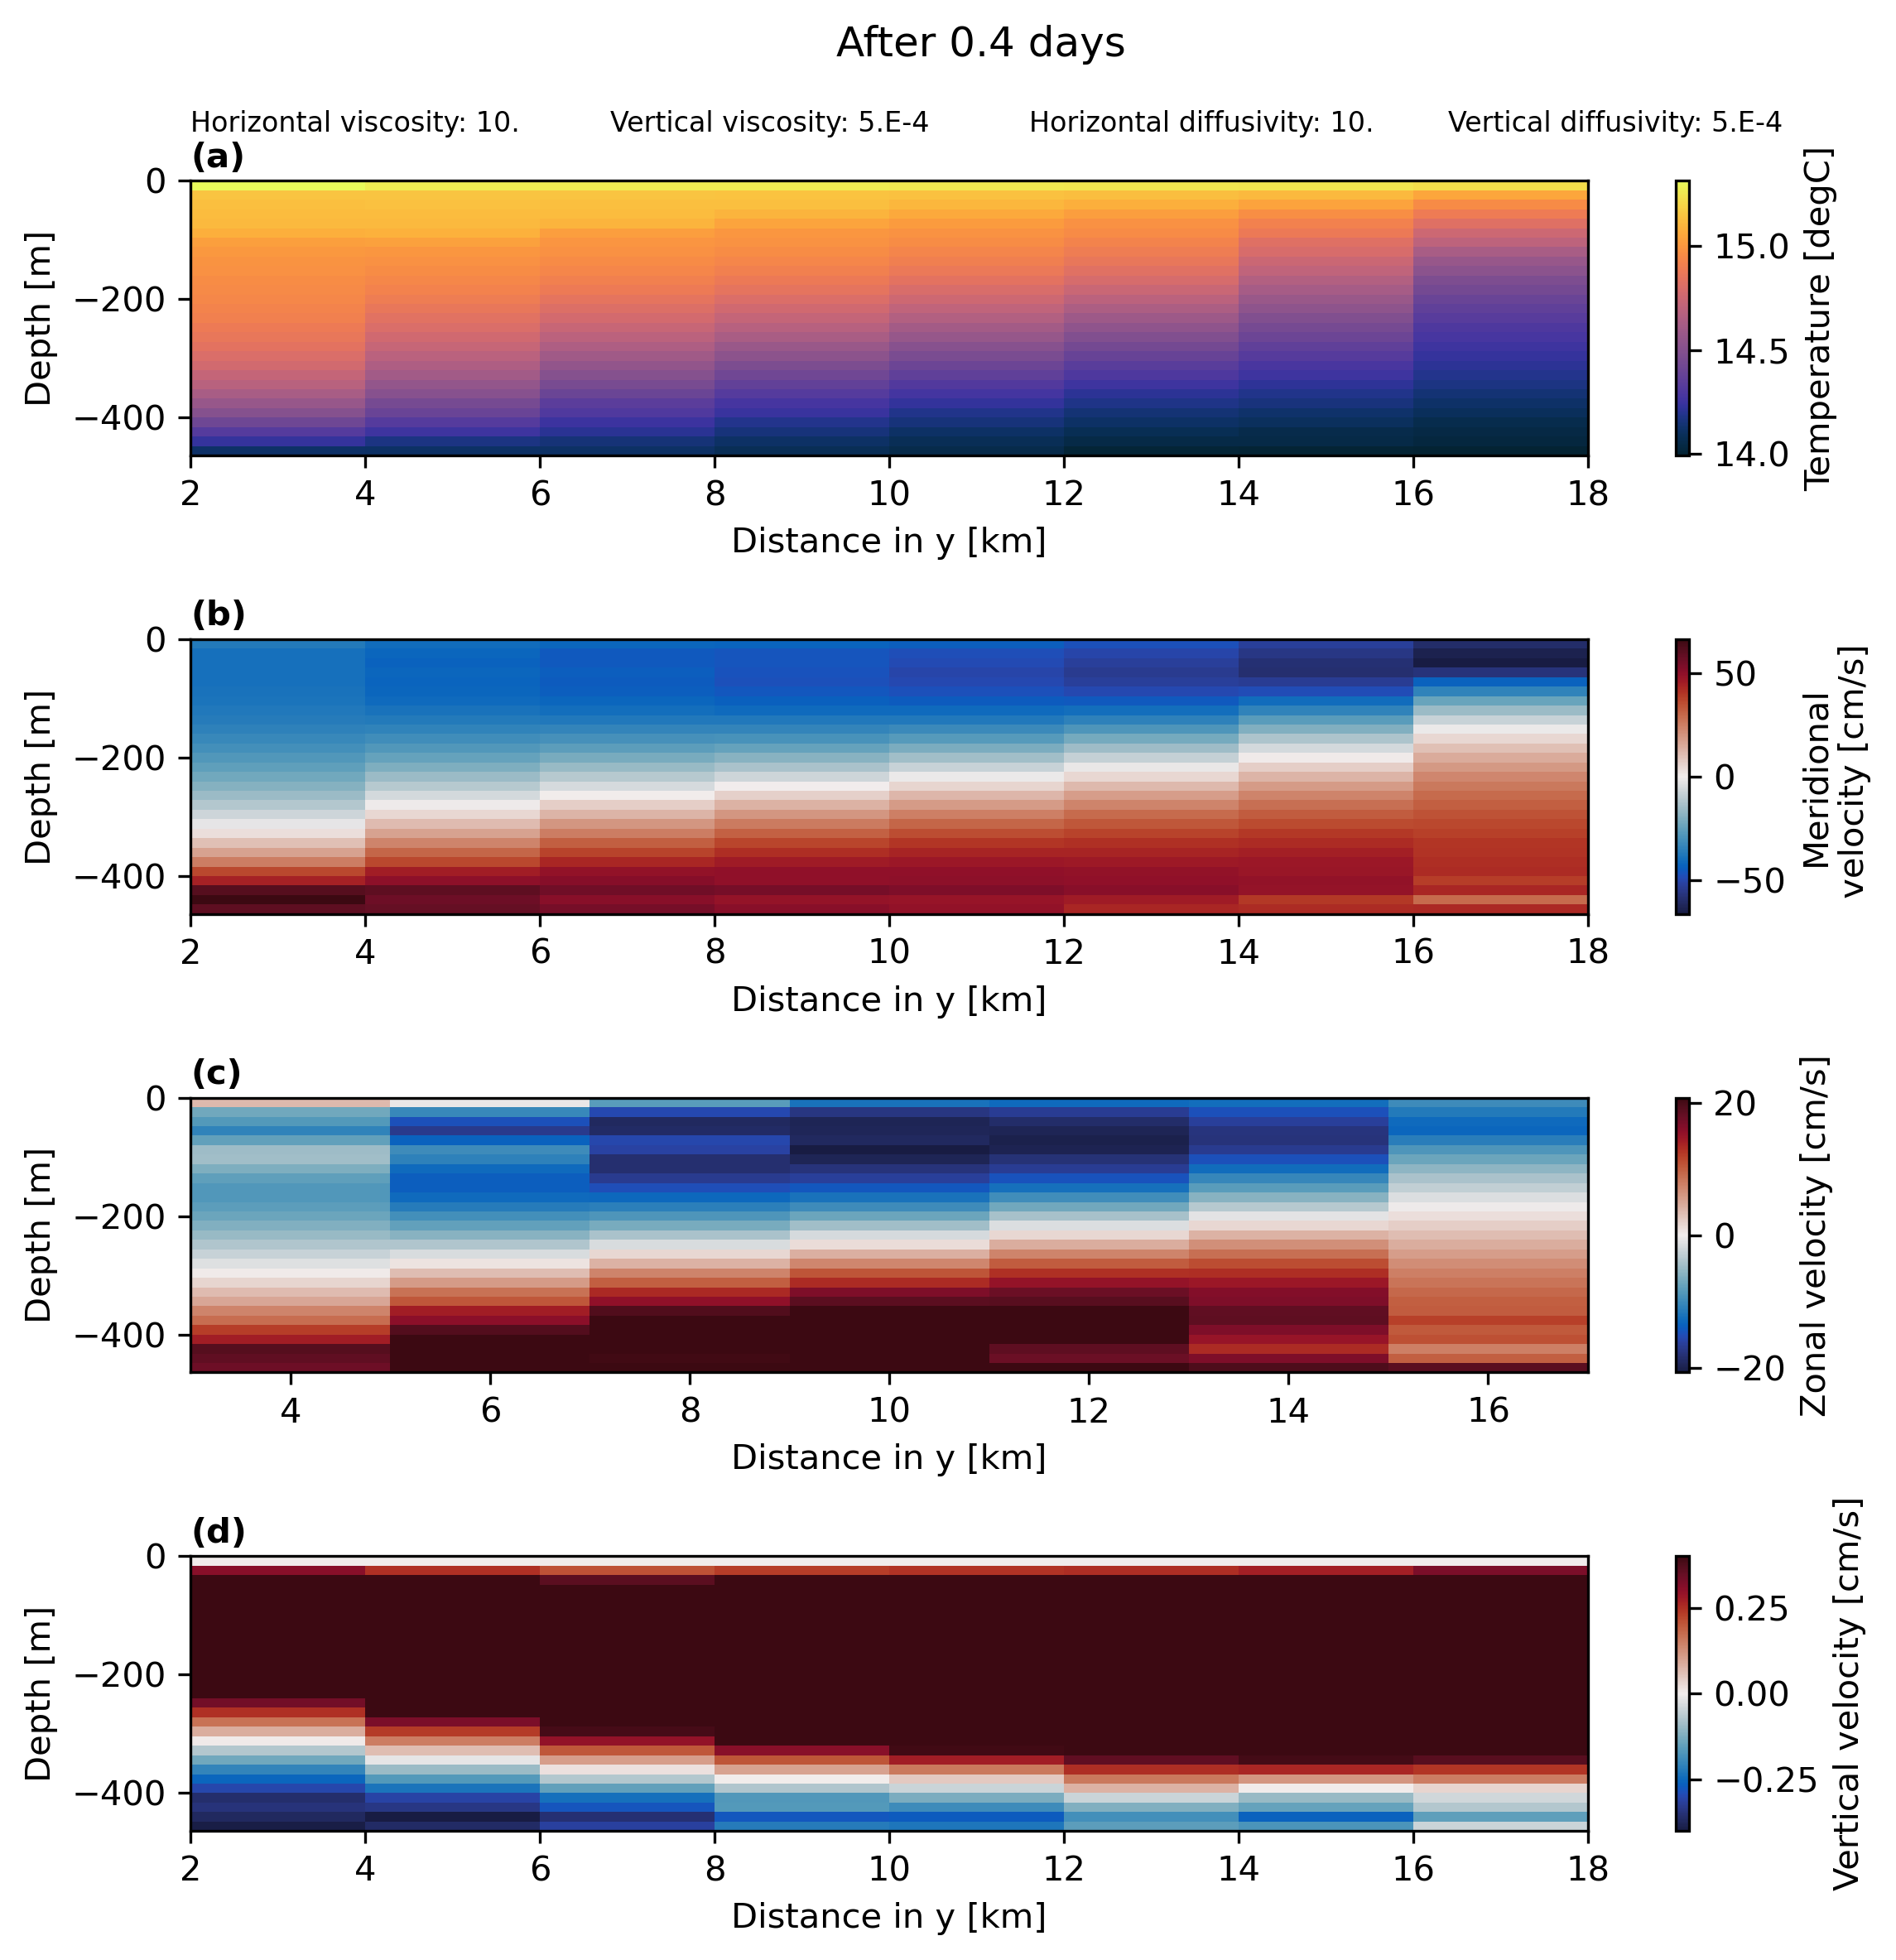

In [60]:
params = {'font.size': 10,
          'figure.figsize': (8, 8),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
tin=0
fig = plt.figure()
gs = GridSpec(nrows=4, ncols=1)
axin = fig.add_subplot(gs[0, 0])
axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

umb=int(len(dsG.Y)*0.4)
bottom=np.where(ds.THETA[tin,:,umb,5].values!=0)[0][-1]

T=ds.THETA[:,:bottom,:,:]
Xin=dsG.X[OBx:OBendx]
Zin=dsG.Z[:bottom]




vmin=np.min(np.ma.masked_array(T[tin,:,umb,OBx:OBendx],mask=mask[:bottom,umb,OBx:OBendx]))
vmax=np.max(np.ma.masked_array(T[tin,:,umb,OBx:OBendx],mask=mask[:bottom,umb,OBx:OBendx]))
cmapi=cmocean.cm.thermal


timein=ds.T[tin]/(60*60*24*360)
cax0=axin.pcolormesh(Xin/1000, Zin, np.ma.masked_array(T[tin,:,umb,OBx:OBendx],mask=mask[:bottom,umb,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
#caxC=axin.contour(Yin/1000, Zin, np.ma.masked_array(T[tin,:,umb,OBx:OBendx]),levels=[15,15.02,15.08,15.2,15.5],colors='cyan')
#plt.clabel(caxC, inline=1, fontsize=8)
cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Temperature [degC]')

axin.text(0, 1.05, '(a)', fontweight='bold', color='k', 
        transform=axin.transAxes)

s=1.18
for i in range(len(plotNames)):
    if i>3:
        s=1.15
        i=i-2
    axin.text(0+i*0.3, s, f'{plotNames[i]}: {plotValues[i]}', color='black', 
            transform=axin.transAxes,fontsize=8)

    
#axin.set_title(f'{plotNames[0]}:{plotValues[0]}, {plotNames[1]}:{plotValues[1]}\n {plotNames[2]}:{plotValues[2]}, {plotNames[3]}:{plotValues[3]}',fontsize=10)


axin = fig.add_subplot(gs[1, 0])

V=ds.VVEL.values[:,:bottom,:,:]

Xin=dsG.X[OBx:OBendx]

vmin=np.min(np.ma.masked_array(V[tin,:,umb,OBx:OBendx]*100,mask=masks[:bottom,umb,OBx:OBendx]))/divV
vmax=-np.min(np.ma.masked_array(V[tin,:,umb,OBx:OBendx]*100,mask=masks[:bottom,umb,OBx:OBendx]))/divV
cmapi=cmocean.cm.balance


axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

timein=ds.T[-tin]/(60*60*24)
cax1=axin.pcolormesh(Xin/1000, Zin, np.ma.masked_array(V[tin,:,umb,OBx:OBendx]*100,mask=masks[:bottom,umb,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax1)
cbar_ax.set_label('Meridional\n velocity [cm/s]')


axin.text(0, 1.05, '(b)', fontweight='bold', color='k', 
        transform=axin.transAxes)


axin = fig.add_subplot(gs[2, 0])

U=ds.UVEL[:,:bottom,:,:]

Xin=dsG.Xp1[OBx+1:OBendx-1]

vmin=np.min(np.ma.masked_array(U[tin,:,umb,OBx+1:OBendx-1],mask=maskw[:bottom,umb,OBx+1:OBendx-1])*100)/divU
vmax=-np.min(np.ma.masked_array(U[tin,:,umb,OBx+1:OBendx-1],mask=maskw[:bottom,umb,OBx+1:OBendx-1])*100)/divU
cmapi=cmocean.cm.balance



axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

timein=ds.T[-tin]/(60*60*24)
cax2=axin.pcolormesh(Xin/1000, Zin, np.ma.masked_array(U[tin,:,umb,OBx+1:OBendx-1]*100,mask=maskw[:bottom,umb,OBx+1:OBendx-1]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax2)
cbar_ax.set_label('Zonal velocity [cm/s]')


axin.text(0, 1.05, '(c)', fontweight='bold', color='k', 
        transform=axin.transAxes)



W=ds.WVEL.values[:,:bottom,:,:] 
Xin=dsG.X[OBx:OBendx]
Zin=dsG.Z[:bottom]

vmin=np.min(np.ma.masked_array(W[tin,:,umb,OBx:OBendx]*100,mask=mask[:bottom,umb,OBx:OBendx]))/divW
vmax=-np.min(np.ma.masked_array(W[tin,:,umb,OBx:OBendx]*100,mask=mask[:bottom,umb,OBx:OBendx]))/divW
cmapi=cmocean.cm.balance

axin = fig.add_subplot(gs[3, 0])

axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

timein=ds.T[-tin]/(60*60*24)
cax3=axin.pcolormesh(Xin/1000, Zin, np.ma.masked_array(W[tin,:,umb,OBx:OBendx]*100,mask=mask[:bottom,umb,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax3)
cbar_ax.set_label('Vertical velocity [cm/s]')


axin.text(0, 1.05, '(d)', fontweight='bold', color='k', 
        transform=axin.transAxes)
tt=0
fig.suptitle(f'After {tt:.1f} days')

fig.tight_layout()
anim = FuncAnimation(fig, animateX,frames=np.arange(0,len(ds.T.values),1), repeat=False,interval=600)

anim.save('../' + str(project)+'/Figures/' +str(ed)+ 'crossectsX'  +'viscHor'+str(plotValues[0])+'viscVert'+str(plotValues[1])+'diffHor'+str(plotValues[2]) +'diffVert'+str(plotValues[3])+ '.mp4', writer=writer, dpi=600)


In [194]:
#Rho Linear EOS
alpha=2*1e-4
RHO=np.zeros(np.shape(ds.THETA.values))
for i in range(len(ds.T)):
    RHO[i,:,:,:]=-999.8*np.ma.masked_array(ds.THETA[i].values-15,mask=mask)*alpha

In [205]:
from math import sin

In [206]:
lat=(22.92+31.70)/2

omega=7.2921*(10**(-5))

f=2*omega*sin(np.deg2rad(lat))

In [207]:
np.sqrt((9.8*(((999.8*15*alpha)-(999.8*14*alpha))/999.8)*200))/f

9356.913622070515

In [69]:
def BottomConc(vel, hfac, nz,nt, ny,loc):
    '''vel: Velocity field (nt,nz,ny)
       hfac: fraction of open cell at center (nz,ny)
       
       
       RETURNS:
       
       BotVel = velocity near bottom (nt,ny)'''
    
    BotVel = np.empty((nt,ny))
    BottomInd = np.argmax(hfac[::-1,:]>0.0,axis=0) # start looking for first no-land cell from the bottom up.
    BottomInd = (np.ones(np.shape(BottomInd))*nz - BottomInd)-loc # Get index of unreversed z axis
    
    for j in range(nt):
        for i in range(ny): 
            BotVel[j,i] = vel[j,int(BottomInd[i]),i] 
                
    
    return (BotVel,BottomInd)


In [70]:
velout1,BottomInd1=BottomConc(V[:,:,:,0],hFacS[:,:,0].values , nz, nt, ny+1,1)
velout2,BottomInd2=BottomConc(V[:,:,:,0],hFacS[:,:,0].values , nz, nt, ny+1,2)

Wvelout1,BottomInd=BottomConc(W[:,:,:,0],hFacC[:,:,0].values , nz, nt, ny,1)
Wvelout2,BottomInd=BottomConc(W[:,:,:,0],hFacC[:,:,0].values , nz, nt, ny,20)

Rhoout1,BottomInd=BottomConc(RHO[:,:,:,0],hFacC[:,:,0].values , nz, nt, ny,1)
Rhoout2,BottomInd=BottomConc(RHO[:,:,:,0],hFacC[:,:,0].values , nz, nt, ny,20)

In [71]:
params = {'font.size': 14,
          'figure.figsize': (12, 12),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [72]:
tin=np.where(ds.T/(24*60*60*360)>9)[0][0]
tinplot=np.where(ds.T/(24*60*60*360)>0)[0][0]

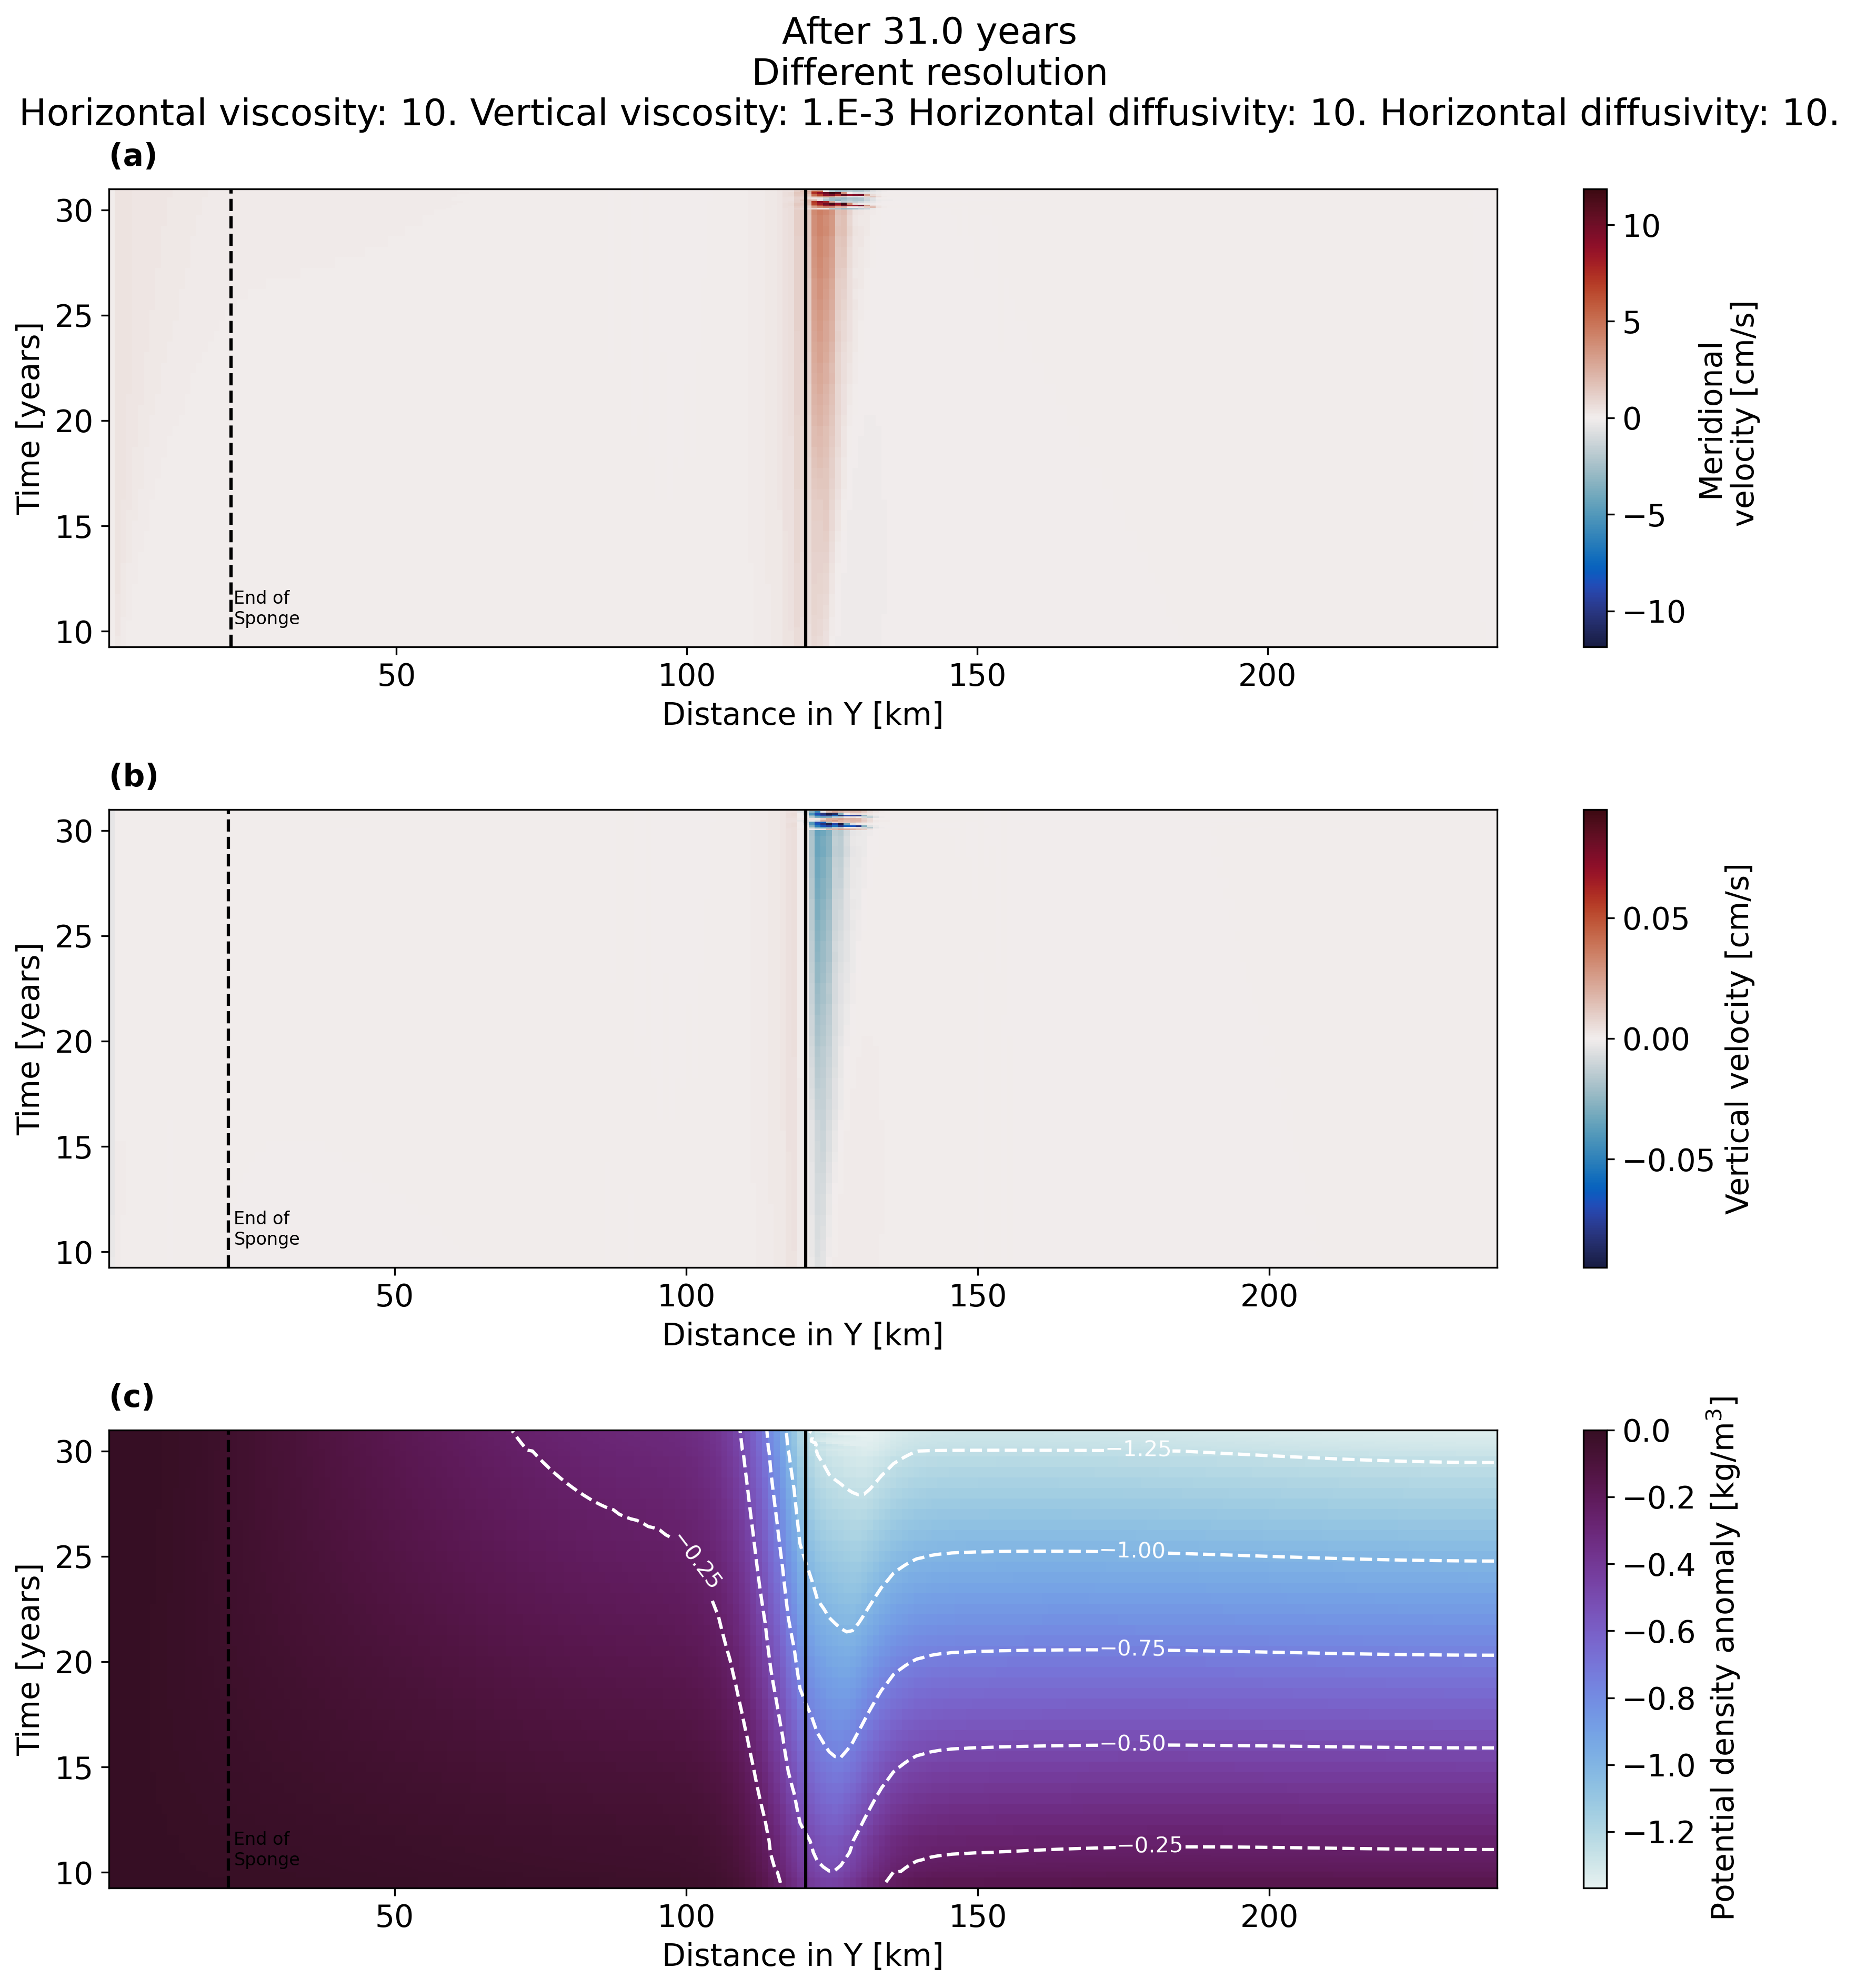

In [73]:
## Hovmöller ##

t=ds.T[tin:]/(60*60*24*360)

fig = plt.figure()
gs = GridSpec(nrows=3, ncols=1)

axin = fig.add_subplot(gs[0, 0])

Yin=dsG.Yp1[OBp:OBendp]

vmin=-np.max(velout1[tinplot:,OB:OBend]*100)/divV
vmax=np.max(velout1[tinplot:,OB:OBend]*100)/divV
cmapi=cmocean.cm.balance

cax0=axin.pcolormesh(Yin/1000, t, velout1[tin:,OBp:OBendp]*100,vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax0)
axin.set(ylabel='Time [years]',xlabel='Distance in Y [km]')
cbar_ax.set_label('Meridional\n velocity [cm/s]')

axin.axvline(dsG.Y[int(umbral)]/1000,c='k')
axin.text(0, 1.05, '(a)', fontweight='bold', color='k',
        transform=axin.transAxes)
axin.axvline(dsG.Y[OB]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

#axin.axhline(31,c='k',linestyle='dashed')
#axin.text(0.7, 0.35, 'Above output is averaged over 10 days\n\nBelow  output is instantaneous snapshot\nevery 10 days', color='k', 
#        transform=axin.transAxes,fontsize=8)

axin = fig.add_subplot(gs[1, 0])


Yin=dsG.Y[OBp:OBendp]

vmin=np.min(Wvelout1[tinplot:,OB:OBend]*100)/divW
vmax=-np.min(Wvelout1[tinplot:,OB:OBend]*100)/divW
cmapi=cmocean.cm.balance

axin.set(ylabel='Time [years]',xlabel='Distance in Y [km]')

cax0=axin.pcolormesh(Yin/1000,t, Wvelout1[tin:,OBp:OBendp]*100,vmin=vmin,vmax=vmax,cmap=cmapi)
cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Vertical velocity [cm/s]')

axin.axvline(dsG.Y[int(umbral)]/1000,c='k')
axin.text(0, 1.05, '(b)', fontweight='bold', color='k',
        transform=axin.transAxes)

axin.axvline(dsG.Y[OB]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

#axin.axhline(31,c='k',linestyle='dashed')
#axin.text(0.7, 0.35, 'Above output is averaged over 10 days\n\nBelow  output is instantaneous snapshot\nevery 10 days', color='k', 
 #       transform=axin.transAxes,fontsize=8)

axin = fig.add_subplot(gs[2, 0])


Yin=dsG.Y[OBp:OBendp]

vmin=np.min(Rhoout1[tinplot:,OB:OBend])
vmax=np.max(Rhoout1[tinplot:,OB:OBend])
cmapi=cmocean.cm.dense

levels=np.linspace(vmin,vmax,15)

axin.set(ylabel='Time [years]',xlabel='Distance in Y [km]')

cax0=axin.pcolormesh(Yin/1000,t, Rhoout1[tin:,OBp:OBendp],vmin=vmin,vmax=vmax,cmap=cmapi)
contours=axin.contour(Yin/1000,t, Rhoout1[tin:,OBp:OBendp],levels=5,colors='white') #np.flip([-0.9,-0.925,-0.95,-1,-1.05])
plt.clabel(contours, inline=1, fontsize=10)
cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Potential density anomaly [kg/m$^3$]')


axin.text(0, 1.05, '(c)', fontweight='bold', color='k',
        transform=axin.transAxes)

axin.axvline(dsG.Y[OB]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)
axin.axvline(dsG.Y[int(umbral)]/1000,c='k')
    
fig.tight_layout()
fig.suptitle(f'After {t[-1]:.1f} years\n Different resolution \n{plotNames[0]}: {plotValues[0]} {plotNames[1]}: {plotValues[1]} {plotNames[2]}: {plotValues[2]} {plotNames[2]}: {plotValues[2]}',y=1.05)


plt.savefig('../' + str(project)+'/Figures/' +str(ed)+ 'LastYearhovmöller' +'viscHor'+str(plotValues[0])+'viscVert'+str(plotValues[1])+'diffHor'+str(plotValues[2]) +'diffVert'+str(plotValues[3])+ '.png',dpi=400)

